# Data Quality Analysis

Reproducible analysis for:
- missing values
- invalid numeric values
- outliers (IQR)
- structured `Carb_g` + `Fiber_g` missingness anomaly - shifted columns

In [5]:
import pandas as pd

DATA_PATH = "../data/original.csv"

raw = pd.read_csv(DATA_PATH, sep=";", dtype=str)

id_cols = ["NDB_No", "Descrip"]
num_cols = [c for c in raw.columns if c not in id_cols]

normalized = raw.copy()
for c in num_cols:
    normalized[c] = normalized[c].str.replace(",", ".", regex=False)

parsed = normalized.copy()
for c in num_cols:
    parsed[c] = pd.to_numeric(parsed[c], errors="coerce")

print(f"Rows: {len(parsed):,} | Columns: {len(parsed.columns)}")

Rows: 10,251 | Columns: 29


In [2]:
# Show all rows that contain at least one missing value
rows_with_missing = parsed[parsed.isna().any(axis=1)].copy()
rows_with_missing["missing_count"] = rows_with_missing.isna().sum(axis=1)
rows_with_missing = rows_with_missing.sort_values("missing_count", ascending=False)

print(f"Rows with at least one missing value: {len(rows_with_missing):,}")
print("Showing all rows with missing values:")
display(rows_with_missing)

Rows with at least one missing value: 122
Showing all rows with missing values:


,NDB_No,Descrip,Energy_kcal,Protein_g,Saturated_fats_g,Fat_g,Carb_g,Fiber_g,Sugar_g,Calcium_mg,...,Thiamin_mg,Riboflavin_mg,Niacin_mg,VitB6_mg,Folate_mcg,VitB12_mcg,VitA_mcg,VitE_mg,VitD2_mcg,missing_count
7307,O058,hare shoulder,144.117,21.13,2.698000e+00,6.58,0.00,0.00,0.00,57.510,...,0.070,0.270,5.040,0.280,2.20,0.00,0.00,NaN,0.00000,2
8381,O060,hare leg,120.217,20.52,9.100000e-01,4.16,0.00,0.00,0.00,53.020,...,0.080,0.220,5.630,0.240,1.95,0.00,0.00,NaN,0.00000,2
219,8082,cereals rte general mills wheat chex,345.000,9.80,4.000000e+00,1.80,82.20,12.20,10.30,NaN,...,0.800,0.900,10.600,1.064,19.00,3.20,317.00,0.68,2.10000,1
340,3172,babyfood juice orange,45.000,0.60,3.500000e-02,0.30,10.20,1.00,8.26,12.000,...,0.045,0.028,0.239,0.054,26.00,0.00,3.00,0.04,0.00000,1
341,33872,inf formula gerber good start 2 soy w iron pdr,501.000,12.50,NaN,25.60,556.00,0.00,55.60,526.000,...,0.301,0.471,5.261,0.301,0.00,1.70,455.00,6.75,7.50000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10001,11435,rutabagas raw,37.000,1.08,2.700000e+01,0.16,8.62,2.30,4.46,43.000,...,0.090,0.040,NaN,0.100,21.00,0.00,0.00,0.30,0.00000,1
10078,13354,"beef chk und bl cntr stk bnless den cut ln 0"" ...",209.000,2653.00,4.730000e+00,11.46,0.00,0.00,NaN,16.000,...,0.090,0.250,3.710,0.461,6.00,4.28,2.00,0.07,0.10000,1
10098,6176,sauce oyster rts,51.000,1.35,4.300000e-02,0.25,10.92,3.00,0.00,32.000,...,0.010,NaN,1.474,0.016,15.00,0.41,0.00,0.00,0.00000,1
10226,8628,cereals rte quaker maple brown sugar life crl,373.000,917.00,7.650000e-01,4.06,78.86,6.30,24.90,349.000,...,1.346,1.526,17.871,1.795,0.00,0.00,0.00,0.56,0.00000,1


In [2]:
# Merge duplicated NDB_No rows when the non-missing values agree.
merged_rows = []
conflict_rows = []
grouped_rows = list(raw.groupby("NDB_No", dropna=False, sort=False))

for ndb_no, group in grouped_rows:
    if len(group) == 1:
        merged_rows.append(group.iloc[0])
        continue

    merged = group.iloc[0].copy()
    conflicts = []

    for column in raw.columns:
        non_missing = group[column].dropna()
        if non_missing.empty:
            merged[column] = pd.NA
            continue

        if non_missing.astype(str).nunique() == 1:
            merged[column] = non_missing.iloc[0]
        else:
            conflicts.append(column)
            merged[column] = non_missing.iloc[0]

    if conflicts:
        conflict_rows.append(
            {
                "NDB_No": ndb_no,
                "rows": len(group),
                "conflicting_columns": ", ".join(conflicts),
            }
        )

    merged_rows.append(merged)

raw = pd.DataFrame(merged_rows, columns=raw.columns).reset_index(drop=True)

# Rebuild normalized and parsed from deduplicated raw to keep downstream counts consistent.
normalized = raw.copy()
for c in num_cols:
    normalized[c] = normalized[c].str.replace(",", ".", regex=False)

parsed = normalized.copy()
for c in num_cols:
    parsed[c] = pd.to_numeric(parsed[c], errors="coerce")

print(f"Rows after merging duplicated NDB_No values: {len(raw):,}")
print(f"Rows after coercion on deduplicated data: {len(parsed):,}")
print(f"Merged duplicated NDB_No groups: {sum(1 for _, group in grouped_rows if len(group) > 1)}")
if conflict_rows:
    print(f"Groups with conflicting non-missing values: {len(conflict_rows)}")
    display(pd.DataFrame(conflict_rows).head(10))

Rows after merging duplicated NDB_No values: 9,319
Rows after coercion on deduplicated data: 9,319
Merged duplicated NDB_No groups: 932


In [4]:
# Missing values
missing = parsed.isna().sum().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

print("Top missing columns:")
print(missing_nonzero.head(10))
print()
print(f"Rows with at least one missing value: {parsed.isna().any(axis=1).sum()} ({parsed.isna().any(axis=1).mean() * 100:.2f}%)")

# Invalid tokens (present in source string but non-numeric after parsing)
invalid_rows = []
for c in num_cols:
    s_raw = normalized[c]
    s_num = parsed[c]
    mask_invalid = s_raw.notna() & (s_raw.str.strip() != "") & s_num.isna()
    cnt = int(mask_invalid.sum())
    if cnt > 0:
        examples = s_raw[mask_invalid].value_counts().head(5).to_dict()
        invalid_rows.append({"column": c, "invalid_count": cnt, "examples": examples})

invalid_df = pd.DataFrame(invalid_rows).sort_values("invalid_count", ascending=False)
print("\nInvalid value summary:")
display(invalid_df)

Top missing columns:
VitA_mcg            9
VitE_mg             8
Selenium_mcg        7
VitC_mg             6
Saturated_fats_g    5
Carb_g              5
Fiber_g             5
Riboflavin_mg       5
VitB12_mcg          5
Fat_g               5
dtype: int64

Rows with at least one missing value: 106 (1.14%)

Invalid value summary:


,column,invalid_count,examples
1,VitE_mg,6,"{'0.33 0.83': 1, '0.29 0.72': 1, '0.69 1.73': ..."
0,Magnesium_mg,1,{'X': 1}


In [5]:
# Outlier summary via Tukey IQR
outlier_rows = []
for c in num_cols:
    s = parsed[c].dropna()
    if len(s) < 10:
        continue
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        continue
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    count = int(((s < lo) | (s > hi)).sum())
    outlier_rows.append({
        "column": c,
        "outlier_count": count,
        "outlier_pct": round(100 * count / len(s), 2),
        "lower_bound": lo,
        "upper_bound": hi,
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
print("Top outlier-heavy columns (IQR):")
display(outlier_df.head(10))

Top outlier-heavy columns (IQR):


,column,outlier_count,outlier_pct,lower_bound,upper_bound
17,VitC_mg,1716,18.43,-4.2000,7.0000
24,VitA_mcg,1563,16.79,-28.5000,47.5000
6,Sugar_g,1326,14.23,-8.2650,13.7750
15,Manganese_mg,1142,12.26,-0.3455,0.5785
9,Magnesium_mg,1058,11.36,-20.0000,60.0000
25,VitE_mg,1057,11.35,-0.7275,1.2125
7,Calcium_mg,1052,11.29,-73.5000,146.5000
14,Copper_mcg,1000,10.73,-0.1440,0.3200
22,Folate_mcg,997,10.70,-28.5000,47.5000
23,VitB12_mcg,970,10.41,-1.6650,2.7750


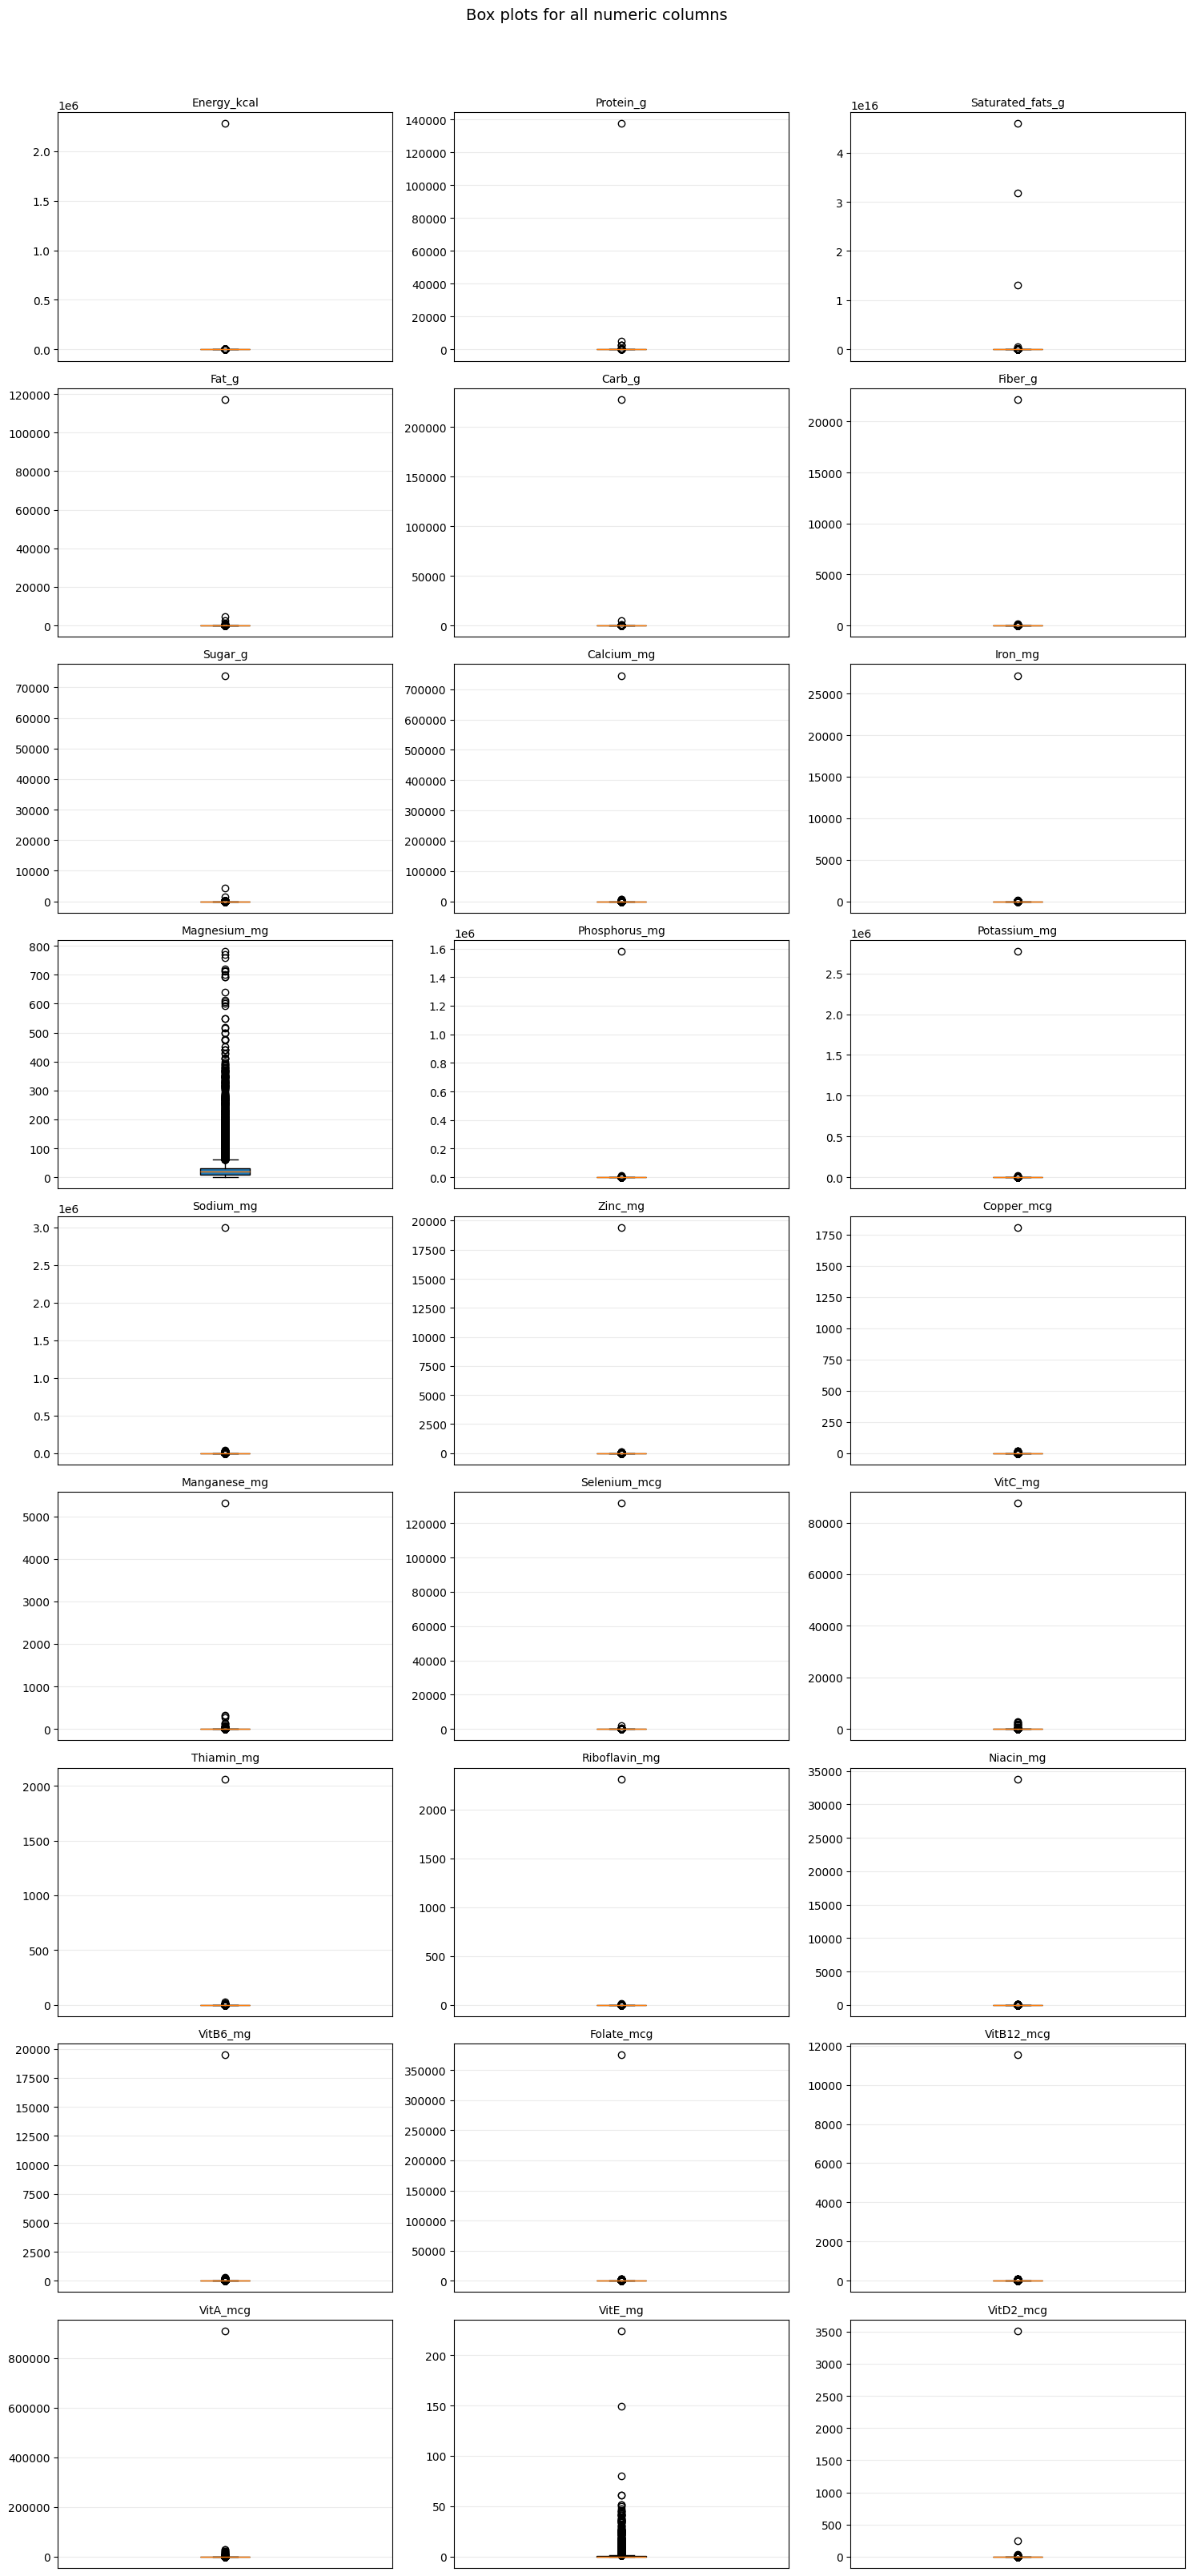

In [6]:
import math
import matplotlib.pyplot as plt

# Box plots for all numeric columns
numeric_data = parsed[num_cols]
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.5))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, column in zip(axes, num_cols):
    series = numeric_data[column].dropna()
    ax.boxplot(series, vert=True, patch_artist=True)
    ax.set_title(column, fontsize=10)
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.25)

for ax in axes[len(num_cols):]:
    ax.axis("off")

fig.suptitle("Box plots for all numeric columns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
import numpy as np

# Robust preprocessing pipeline for numeric features
model_df = parsed.copy()

# 1) Flag and null-out impossible negative values (nutrients should be non-negative)
neg_flag_cols = []
for c in num_cols:
    neg_mask = model_df[c] < 0
    flag_col = f"{c}__was_negative"
    model_df[flag_col] = neg_mask.astype(int)
    neg_flag_cols.append(flag_col)
    model_df.loc[neg_mask, c] = pd.NA
print("Step 1 done.")

# 2) Missingness indicator
missing_flag_cols = []
for c in num_cols:
    flag_col = f"{c}__was_missing"
    model_df[flag_col] = model_df[c].isna().astype(int)
    missing_flag_cols.append(flag_col)
print("Step 2 done.")

# 3) High-end quantile clipping with audit flags (winsorization)
clip_high_cols = []
clip_bounds = {}

for c in num_cols:
    s = model_df[c].dropna()
    if len(s) < 20:
        continue

    hi = s.quantile(0.99)
    clip_bounds[c] = {"q99": float(hi)}

    high_col = f"{c}__was_clipped_high"
    model_df[high_col] = (model_df[c] > hi).fillna(False).astype(int)
    clip_high_cols.append(high_col)

    model_df[c] = model_df[c].clip(lower=0, upper=hi)
print("Step 3 done.")

# 4) Log-transform highly skewed non-negative columns
log_cols = []
for c in num_cols:
    s = model_df[c].dropna()
    if len(s) < 20:
        continue
    if s.min() >= 0 and s.skew() > 1.0:
        model_df[c] = model_df[c].map(lambda x: np.nan if pd.isna(x) else float(np.log1p(x)))
        log_cols.append(c)
print("Step 4 done.")

# 5) Median impute + robust scale
feature_matrix = model_df[num_cols].astype(float)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(feature_matrix)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)
scaled_cols = [f"{c}__scaled" for c in num_cols]
scaled_df = pd.DataFrame(X_scaled, columns=scaled_cols, index=model_df.index)
print("Step 5 done.")

# Final dataset: IDs + scaled numeric + audit flags
audit_flag_cols = missing_flag_cols + neg_flag_cols + clip_high_cols
processed_df = pd.concat([model_df[id_cols], scaled_df, model_df[audit_flag_cols]], axis=1)

print("Robust preprocessing finished.")
print(f"Rows: {len(processed_df):,}")
print(f"Scaled numeric features: {len(scaled_cols)}")
print(f"Audit flag features: {len(audit_flag_cols)}")
print(f"Log-transformed columns: {len(log_cols)}")

display(processed_df.head())

if log_cols:
    print("\nColumns log-transformed (skew > 1 and non-negative):")
    print(log_cols)

print("\nExample clipping bounds (first 8 columns):")
display(pd.DataFrame(clip_bounds).T.head(8))

Step 1 done.
Step 2 done.
Step 3 done.
Step 4 done.


C:\Users\tomas\AppData\Local\Temp\ipykernel_12776\730186131.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df[high_col] = (model_df[c] > hi).fillna(False).astype(int)
C:\Users\tomas\AppData\Local\Temp\ipykernel_12776\730186131.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df[high_col] = (model_df[c] > hi).fillna(False).astype(int)
C:\Users\tomas\AppData\Local\Temp\ipykernel_12776\730186131.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

Step 5 done.
Robust preprocessing finished.
Rows: 10,251
Scaled numeric features: 27
Audit flag features: 81
Log-transformed columns: 26


AttributeError: 'DataFrame' object has no attribute 'heaSd'

Clipped values per column:


,column,clipped_high
7,Calcium_mg,94
4,Carb_g,94
14,Copper_mcg,94
5,Fiber_g,94
22,Folate_mcg,94
9,Magnesium_mg,94
15,Manganese_mg,94
20,Niacin_mg,94
10,Phosphorus_mg,94
11,Potassium_mg,94


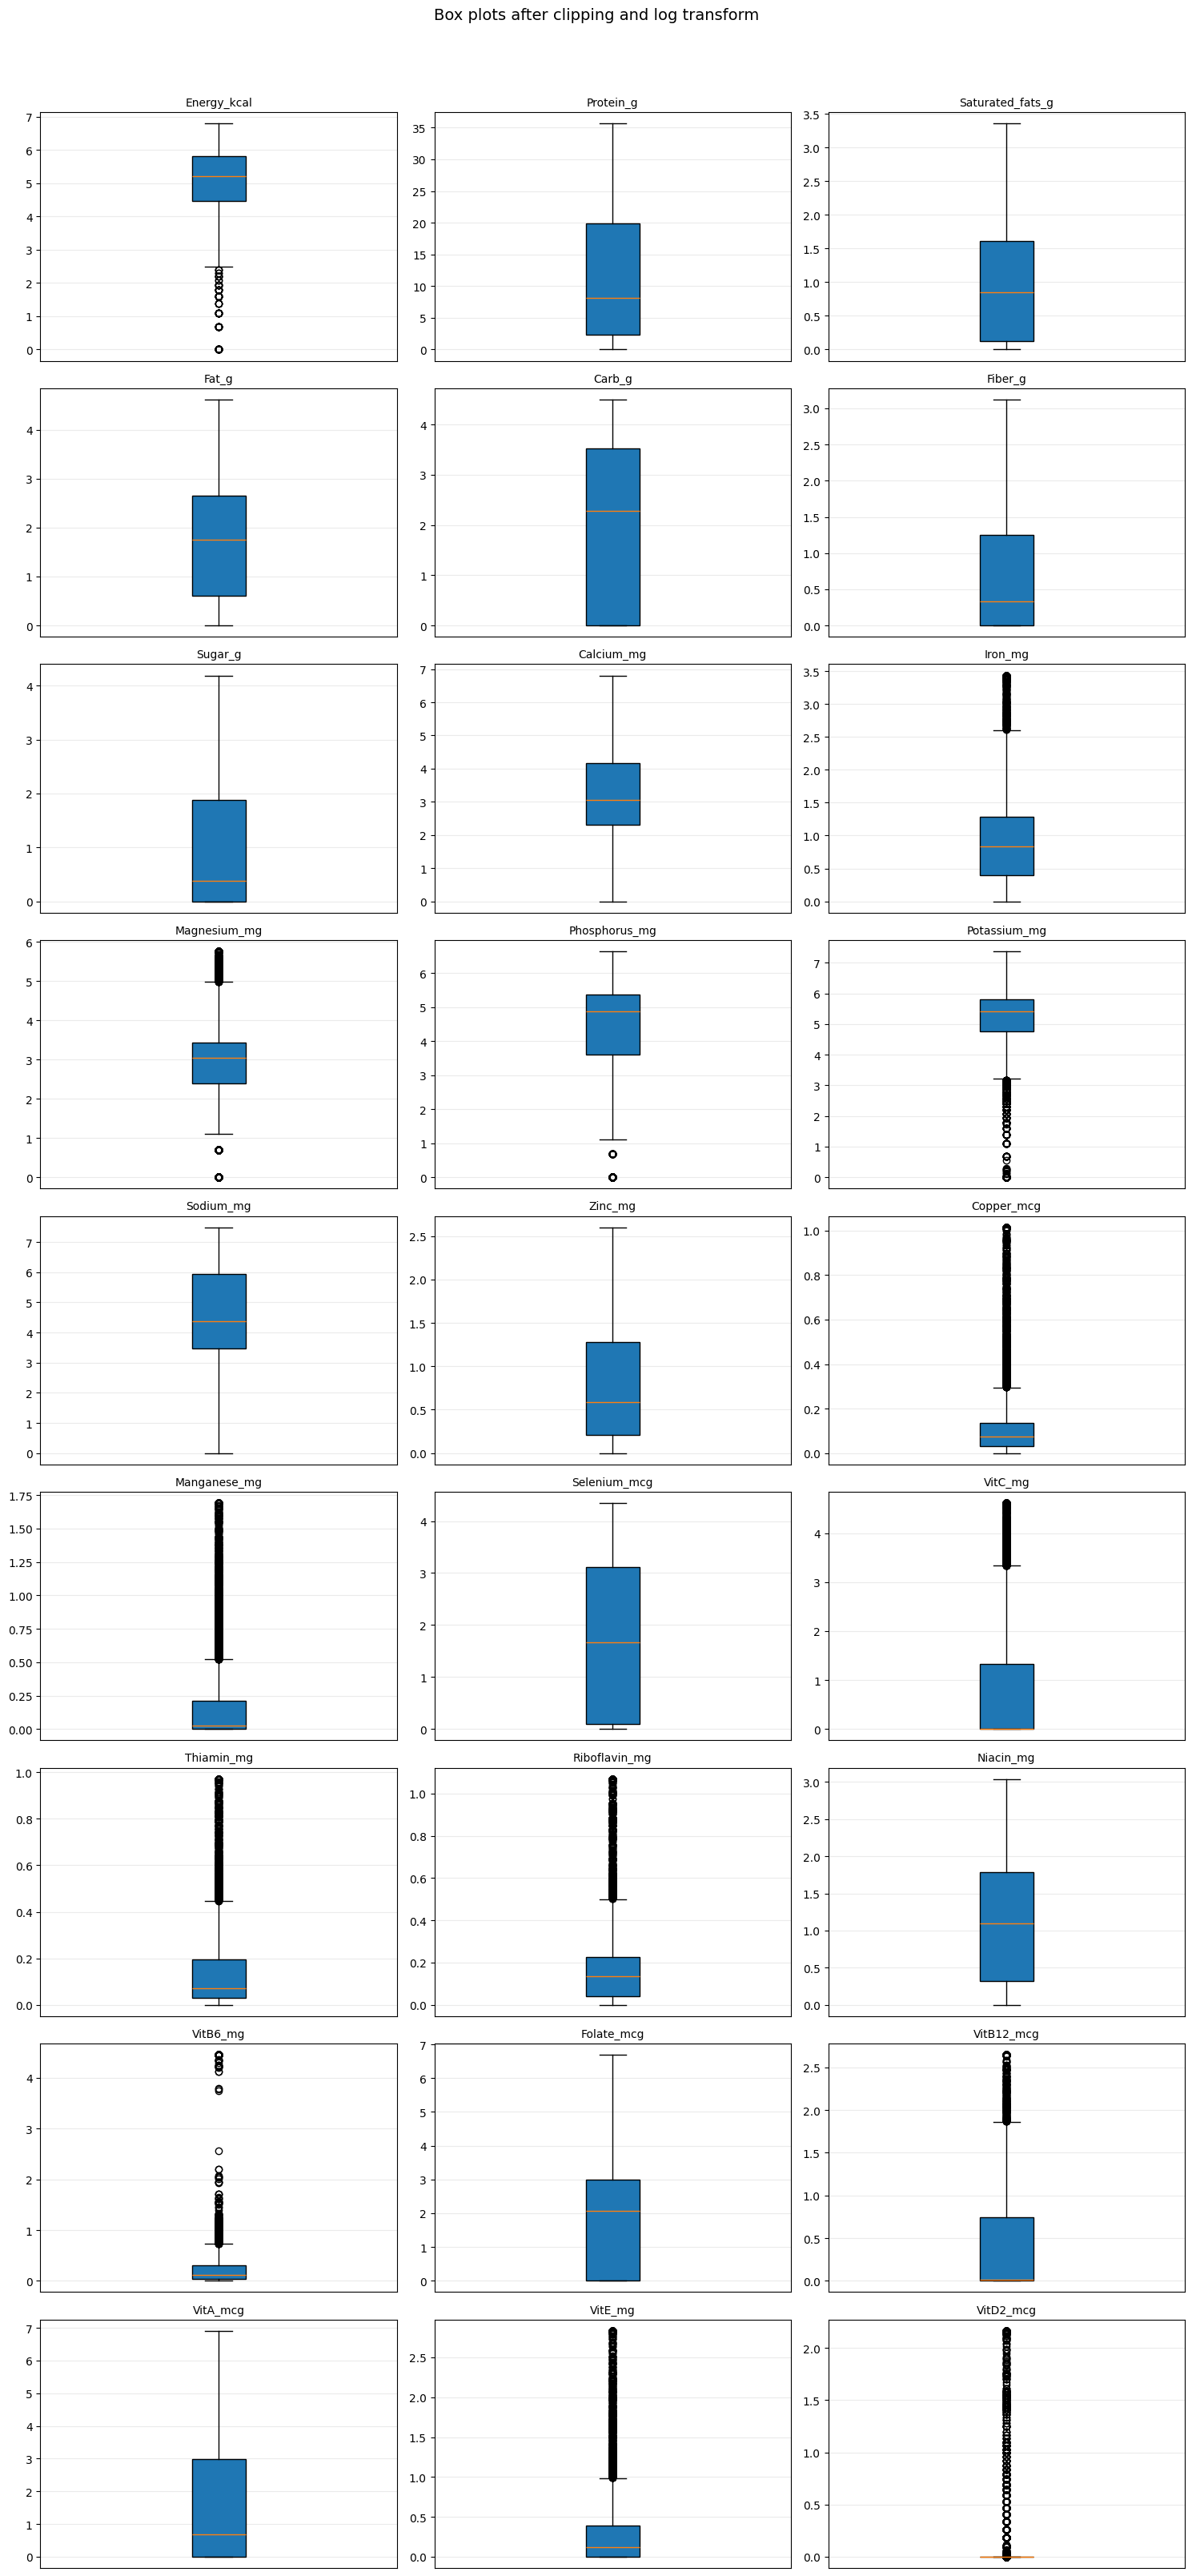

In [8]:
import math
import matplotlib.pyplot as plt

# Summary of clipped values per column
clip_summary_rows = []
for column in clip_bounds:
    high_col = f"{column}__was_clipped_high"
    high_count = int(model_df[high_col].sum()) if high_col in model_df else 0
    clip_summary_rows.append(
        {
            "column": column,
            "clipped_high": high_count,
        }
    )

clip_summary_df = pd.DataFrame(clip_summary_rows).sort_values(
    ["clipped_high", "column"], ascending=[False, True]
)
print("Clipped values per column:")
display(clip_summary_df)

# Box plots after clipping and log transformation
plot_data = model_df[num_cols]
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.5))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, column in zip(axes, num_cols):
    series = plot_data[column].dropna()
    if series.empty:
        ax.axis("off")
        continue
    ax.boxplot(series, vert=True, patch_artist=True)
    ax.set_title(column, fontsize=10)
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.25)

for ax in axes[len(num_cols):]:
    ax.axis("off")

fig.suptitle("Box plots after clipping and log transform", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Dataset variants prepared:
- Imputed rows: 10,251
- Drop-missing rows: 10,118
- Rows removed in drop-missing variant: 133

=== Variant: imputed ===
Best k from K-Means silhouette search: 2


,k,silhouette
0,2,0.380128
1,3,0.235702
6,8,0.232424
2,4,0.231999
5,7,0.224646
7,9,0.222980
4,6,0.218359
3,5,0.205273
8,10,0.201540



=== Variant: drop_missing ===
Best k from K-Means silhouette search: 2


,k,silhouette
0,2,0.375775
2,4,0.251788
1,3,0.239878
6,8,0.231713
7,9,0.224806
5,7,0.222768
4,6,0.214195
8,10,0.207984
3,5,0.201317



=== Clustering comparison summary ===


,variant,model,samples_used,params,clusters,noise_pct,silhouette,davies_bouldin,calinski_harabasz
5,drop_missing,DBSCAN,4000,"eps=1.2, min_samples=20",8,77.900,0.418054,0.568340,1073.859612
3,drop_missing,KMeans,10118,k=2,2,0.000,0.381368,1.771345,2185.509940
4,drop_missing,HAC,3000,"k=2, linkage=ward",2,0.000,0.169506,1.865249,575.002659
2,imputed,DBSCAN,4000,"eps=1.0, min_samples=20",9,84.225,0.431998,0.563474,1454.963775
1,imputed,HAC,3000,"k=2, linkage=ward",2,0.000,0.397492,1.807104,611.818917
0,imputed,KMeans,10251,k=2,2,0.000,0.382106,1.771028,2217.178963


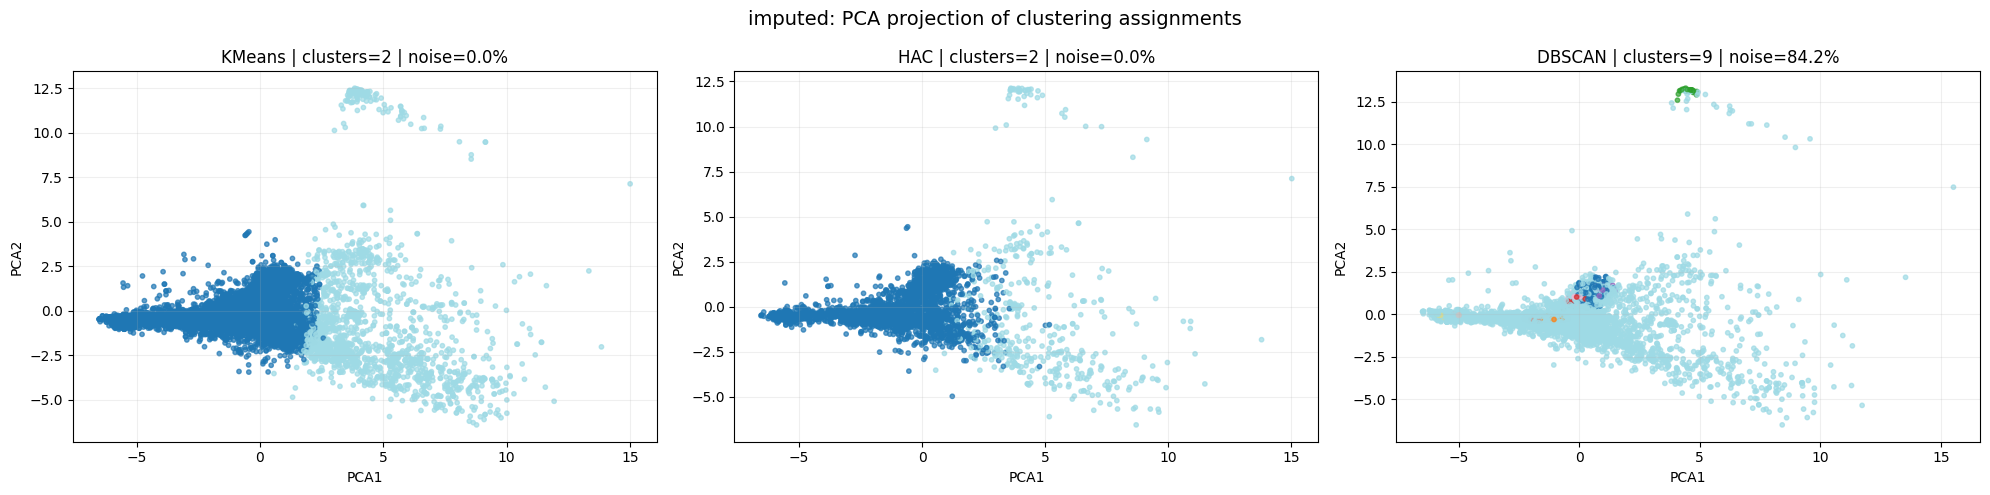

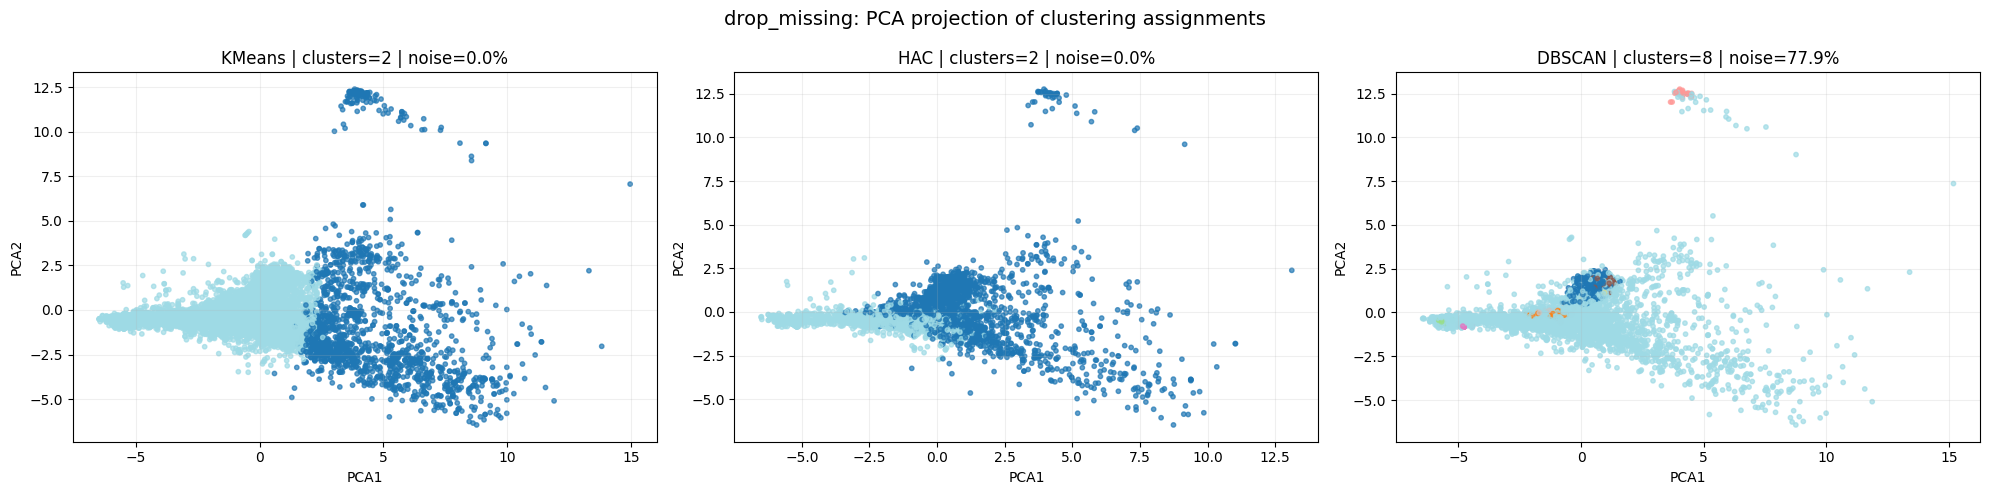


=== Practical interpretation ===
- drop_missing: best silhouette from DBSCAN (eps=1.2, min_samples=20) = 0.418; Davies-Bouldin=0.568, Calinski-Harabasz=1073.9.
- imputed: best silhouette from DBSCAN (eps=1.0, min_samples=20) = 0.432; Davies-Bouldin=0.563, Calinski-Harabasz=1455.0.

Other clustering models worth trying on this dataset:
1. Gaussian Mixture Models (soft clustering, probabilistic assignments)
2. BIRCH (efficient hierarchical clustering for larger datasets)
3. Spectral Clustering (captures non-convex manifold-like structure)
4. OPTICS (density-based alternative with varying density support)
5. HDBSCAN (robust density clustering; better than DBSCAN on mixed densities, if available)


In [7]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Build two feature variants
X_imputed = pd.DataFrame(X_scaled, columns=num_cols, index=model_df.index)

drop_mask = model_df[num_cols].notna().all(axis=1)
X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
drop_scaler = RobustScaler()
X_drop = pd.DataFrame(
    drop_scaler.fit_transform(X_drop_raw),
    columns=num_cols,
    index=X_drop_raw.index,
)

print("Dataset variants prepared:")
print(f"- Imputed rows: {len(X_imputed):,}")
print(f"- Drop-missing rows: {len(X_drop):,}")
print(f"- Rows removed in drop-missing variant: {len(X_imputed) - len(X_drop):,}")


def to_sample(X_df, max_rows, seed):
    if len(X_df) <= max_rows:
        return X_df.copy()
    idx = np.random.default_rng(seed).choice(X_df.index.values, size=max_rows, replace=False)
    return X_df.loc[idx].copy()


def choose_best_kmeans_k(X_df, k_min=2, k_max=10):
    upper = min(k_max, len(X_df) - 1)
    k_values = list(range(k_min, upper + 1))
    rows = []

    for k in k_values:
        labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_df)
        sil = silhouette_score(X_df, labels)
        rows.append({"k": k, "silhouette": sil})

    df = pd.DataFrame(rows).sort_values("silhouette", ascending=False)
    best_k = int(df.iloc[0]["k"])
    return best_k, df


def evaluate_labels(X_df, labels):
    labels = np.asarray(labels)
    noise_mask = labels == -1
    cluster_labels = np.unique(labels[~noise_mask])
    n_clusters = len(cluster_labels)
    noise_pct = float(100 * noise_mask.mean())

    if n_clusters < 2:
        return {
            "clusters": n_clusters,
            "noise_pct": noise_pct,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    if noise_mask.any():
        X_eval = X_df.loc[~noise_mask]
        labels_eval = labels[~noise_mask]
    else:
        X_eval = X_df
        labels_eval = labels

    return {
        "clusters": n_clusters,
        "noise_pct": noise_pct,
        "silhouette": float(silhouette_score(X_eval, labels_eval)),
        "davies_bouldin": float(davies_bouldin_score(X_eval, labels_eval)),
        "calinski_harabasz": float(calinski_harabasz_score(X_eval, labels_eval)),
    }


def fit_dbscan_grid(X_df, eps_values, min_samples_values):
    best = None

    for eps in eps_values:
        for min_samples in min_samples_values:
            labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_df)
            metrics = evaluate_labels(X_df, labels)

            row = {
                "eps": eps,
                "min_samples": min_samples,
                **metrics,
                "labels": labels,
            }

            if best is None:
                best = row
                continue

            current_score = row["silhouette"] if not np.isnan(row["silhouette"]) else -np.inf
            best_score = best["silhouette"] if not np.isnan(best["silhouette"]) else -np.inf
            if current_score > best_score:
                best = row

    return best


variants = {
    "imputed": X_imputed,
    "drop_missing": X_drop,
}

summary_rows = []
plot_payload = {}

for variant_name, X_variant in variants.items():
    print(f"\n=== Variant: {variant_name} ===")

    # Keep HAC/DBSCAN tractable on large datasets
    X_k_tune = to_sample(X_variant, max_rows=5000, seed=RANDOM_STATE)
    X_hac = to_sample(X_variant, max_rows=3000, seed=RANDOM_STATE + 1)
    X_db = to_sample(X_variant, max_rows=4000, seed=RANDOM_STATE + 2)

    best_k, k_search_df = choose_best_kmeans_k(X_k_tune)
    print(f"Best k from K-Means silhouette search: {best_k}")
    display(k_search_df)

    # K-Means (full variant)
    km_labels = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE).fit_predict(X_variant)
    km_metrics = evaluate_labels(X_variant, km_labels)
    summary_rows.append(
        {
            "variant": variant_name,
            "model": "KMeans",
            "samples_used": len(X_variant),
            "params": f"k={best_k}",
            **km_metrics,
        }
    )

    # HAC (sampled for runtime)
    hac_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X_hac)
    hac_metrics = evaluate_labels(X_hac, hac_labels)
    summary_rows.append(
        {
            "variant": variant_name,
            "model": "HAC",
            "samples_used": len(X_hac),
            "params": f"k={best_k}, linkage=ward",
            **hac_metrics,
        }
    )

    # DBSCAN (grid search on sampled subset)
    db_result = fit_dbscan_grid(
        X_db,
        eps_values=[0.8, 1.0, 1.2, 1.5, 2.0],
        min_samples_values=[5, 10, 20],
    )
    summary_rows.append(
        {
            "variant": variant_name,
            "model": "DBSCAN",
            "samples_used": len(X_db),
            "params": f"eps={db_result['eps']}, min_samples={db_result['min_samples']}",
            "clusters": db_result["clusters"],
            "noise_pct": db_result["noise_pct"],
            "silhouette": db_result["silhouette"],
            "davies_bouldin": db_result["davies_bouldin"],
            "calinski_harabasz": db_result["calinski_harabasz"],
        }
    )

    plot_payload[variant_name] = {
        "KMeans": (X_variant, km_labels),
        "HAC": (X_hac, hac_labels),
        "DBSCAN": (X_db, db_result["labels"]),
    }

summary_df = pd.DataFrame(summary_rows).sort_values(["variant", "silhouette"], ascending=[True, False])
print("\n=== Clustering comparison summary ===")
display(summary_df)


def plot_variant_results(variant_name, variant_payload):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    for ax, (model_name, (X_plot, labels)) in zip(axes, variant_payload.items()):
        coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_plot)
        labels = np.asarray(labels)

        if (labels == -1).any():
            color_labels = labels.copy()
            color_labels[labels == -1] = color_labels.max() + 1
            scatter = ax.scatter(coords[:, 0], coords[:, 1], c=color_labels, s=10, alpha=0.7, cmap="tab20")
        else:
            scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, s=10, alpha=0.7, cmap="tab20")

        n_clusters = len(np.unique(labels[labels != -1]))
        noise_pct = 100 * (labels == -1).mean()
        ax.set_title(f"{model_name} | clusters={n_clusters} | noise={noise_pct:.1f}%")
        ax.set_xlabel("PCA1")
        ax.set_ylabel("PCA2")
        ax.grid(alpha=0.2)

    fig.suptitle(f"{variant_name}: PCA projection of clustering assignments", fontsize=14)
    plt.tight_layout()
    plt.show()


for variant_name, payload in plot_payload.items():
    plot_variant_results(variant_name, payload)

print("\n=== Practical interpretation ===")
for variant_name in summary_df["variant"].unique():
    sub = summary_df[summary_df["variant"] == variant_name]
    best = sub.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).head(1)
    if best.empty:
        print(f"- {variant_name}: no model produced at least 2 non-noise clusters with valid silhouette.")
    else:
        r = best.iloc[0]
        print(
            f"- {variant_name}: best silhouette from {r['model']} ({r['params']}) = {r['silhouette']:.3f}; "
            f"Davies-Bouldin={r['davies_bouldin']:.3f}, Calinski-Harabasz={r['calinski_harabasz']:.1f}."
        )

print("\nOther clustering models worth trying on this dataset:")
print("1. Gaussian Mixture Models (soft clustering, probabilistic assignments)")
print("2. BIRCH (efficient hierarchical clustering for larger datasets)")
print("3. Spectral Clustering (captures non-convex manifold-like structure)")
print("4. OPTICS (density-based alternative with varying density support)")
print("5. HDBSCAN (robust density clustering; better than DBSCAN on mixed densities, if available)")

Higher-cluster model comparison (k >= 3):


,variant,model,k,samples_used,silhouette,davies_bouldin,calinski_harabasz
24,drop_missing,KMeans,3,5000,0.259784,1.674983,1072.937883
28,drop_missing,KMeans,4,5000,0.250942,1.263578,1129.842346
36,drop_missing,KMeans,6,5000,0.217051,1.365721,1103.867654
40,drop_missing,KMeans,8,5000,0.213179,1.502017,999.308943
45,drop_missing,HAC,10,5000,0.207252,1.626056,766.705473
41,drop_missing,HAC,8,5000,0.204809,1.622816,838.771211
32,drop_missing,KMeans,5,5000,0.203829,1.344205,1137.803608
44,drop_missing,KMeans,10,5000,0.202889,1.493330,899.260878
43,drop_missing,BIRCH,8,5000,0.196690,1.644583,828.516535
29,drop_missing,HAC,4,5000,0.191420,1.479457,915.366372


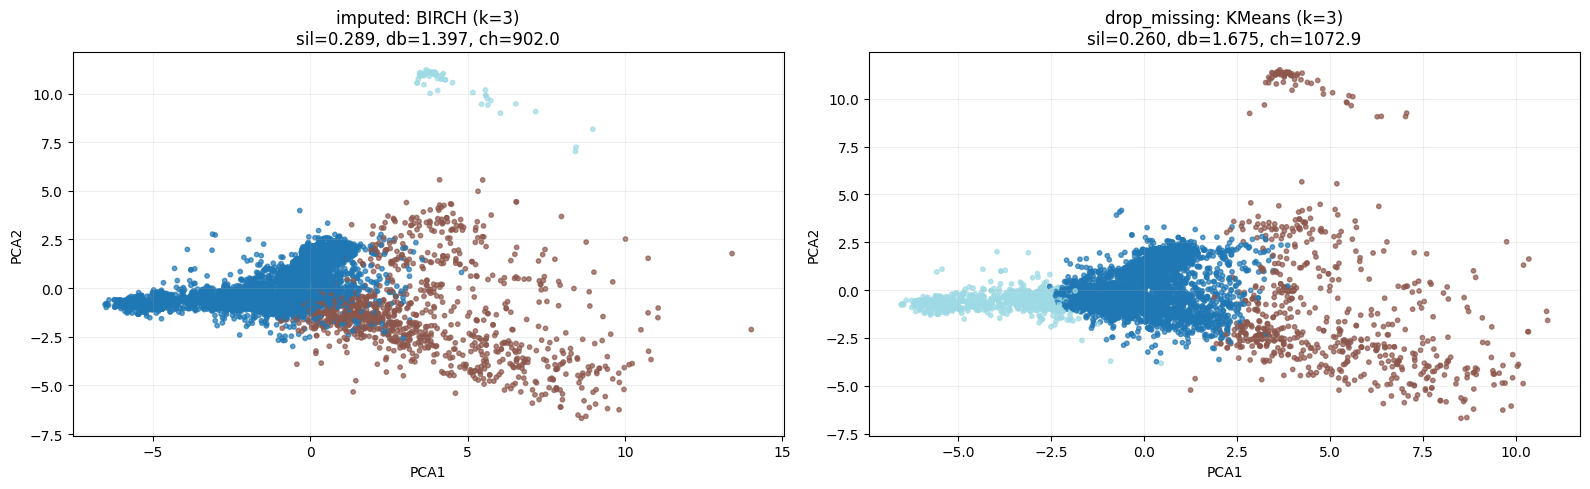

Suggested high-cluster candidates:
- imputed: BIRCH with k=3 (silhouette=0.289, davies_bouldin=1.397, calinski_harabasz=902.0)
- drop_missing: KMeans with k=3 (silhouette=0.260, davies_bouldin=1.675, calinski_harabasz=1072.9)


In [8]:
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Explore richer segmentations with higher cluster counts
k_grid = [3, 4, 5, 6, 8, 10]

high_k_rows = []
plot_best_payload = {}

for variant_name, X_variant in variants.items():
    X_eval = to_sample(X_variant, max_rows=5000, seed=RANDOM_STATE + 200)

    for k in k_grid:
        if len(X_eval) <= k:
            continue

        model_specs = [
            ("KMeans", KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)),
            ("HAC", AgglomerativeClustering(n_clusters=k, linkage="ward")),
            ("GMM", GaussianMixture(n_components=k, random_state=RANDOM_STATE, covariance_type="full")),
            ("BIRCH", Birch(n_clusters=k, threshold=0.5)),
        ]

        for model_name, model in model_specs:
            if model_name == "GMM":
                labels = model.fit_predict(X_eval)
            else:
                labels = model.fit_predict(X_eval)

            uniq = np.unique(labels)
            if len(uniq) < 2:
                sil = np.nan
                dbi = np.nan
                ch = np.nan
            else:
                sil = float(silhouette_score(X_eval, labels))
                dbi = float(davies_bouldin_score(X_eval, labels))
                ch = float(calinski_harabasz_score(X_eval, labels))

            high_k_rows.append(
                {
                    "variant": variant_name,
                    "model": model_name,
                    "k": int(k),
                    "samples_used": int(len(X_eval)),
                    "silhouette": sil,
                    "davies_bouldin": dbi,
                    "calinski_harabasz": ch,
                    "labels": labels,
                }
            )

high_k_df = pd.DataFrame(high_k_rows)

summary_cols = [
    "variant",
    "model",
    "k",
    "samples_used",
    "silhouette",
    "davies_bouldin",
    "calinski_harabasz",
]

print("Higher-cluster model comparison (k >= 3):")
display(
    high_k_df[summary_cols].sort_values(
        ["variant", "silhouette", "calinski_harabasz"],
        ascending=[True, False, False],
    )
)

# Pick best higher-k model per variant by silhouette then Calinski-Harabasz
for variant_name in high_k_df["variant"].unique():
    subset = high_k_df[high_k_df["variant"] == variant_name].dropna(subset=["silhouette"])
    if subset.empty:
        continue

    best_row = subset.sort_values(
        ["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    ).iloc[0]

    # Recreate evaluation sample to match labels
    X_plot = to_sample(variants[variant_name], max_rows=5000, seed=RANDOM_STATE + 200)
    plot_best_payload[variant_name] = {
        "X": X_plot,
        "labels": best_row["labels"],
        "model": best_row["model"],
        "k": int(best_row["k"]),
        "silhouette": float(best_row["silhouette"]),
        "davies_bouldin": float(best_row["davies_bouldin"]),
        "calinski_harabasz": float(best_row["calinski_harabasz"]),
    }

fig, axes = plt.subplots(1, max(1, len(plot_best_payload)), figsize=(8 * max(1, len(plot_best_payload)), 5))
if len(plot_best_payload) == 1:
    axes = [axes]

for ax, (variant_name, payload) in zip(axes, plot_best_payload.items()):
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(payload["X"])
    ax.scatter(coords[:, 0], coords[:, 1], c=payload["labels"], s=10, alpha=0.7, cmap="tab20")
    ax.set_title(
        f"{variant_name}: {payload['model']} (k={payload['k']})\n"
        f"sil={payload['silhouette']:.3f}, db={payload['davies_bouldin']:.3f}, ch={payload['calinski_harabasz']:.1f}"
    )
    ax.set_xlabel("PCA1")
    ax.set_ylabel("PCA2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Suggested high-cluster candidates:")
for variant_name, payload in plot_best_payload.items():
    print(
        f"- {variant_name}: {payload['model']} with k={payload['k']} "
        f"(silhouette={payload['silhouette']:.3f}, "
        f"davies_bouldin={payload['davies_bouldin']:.3f}, "
        f"calinski_harabasz={payload['calinski_harabasz']:.1f})"
    )

Cluster sizes:


,count,pct
cluster,,
0,955,9.44
1,5823,57.55
2,125,1.24
3,3215,31.78


Cluster profile matrix (mean transformed values):


cluster,0,1,2,3
Energy_kcal,5.766047,5.319462,4.609758,4.325421
Protein_g,14.049675,15.248164,19.806800,2.456072
Saturated_fats_g,0.985135,1.247416,0.559869,0.536885
Fat_g,2.060988,2.090175,1.026298,1.028195
Carb_g,3.573271,1.828069,0.035954,2.238476
Fiber_g,1.851097,0.566190,0.024944,0.626600
Sugar_g,1.356746,0.839965,0.033599,1.322844
Calcium_mg,4.495145,3.285439,3.039705,2.503353
Iron_mg,1.815417,1.082983,0.521354,0.397293
Magnesium_mg,4.665586,3.207433,3.434120,1.523858


Top columns driving cluster separation:


...

Top distinguishing columns per cluster (largest absolute z-delta):


,cluster_mean,global_mean,z_delta
feature,,,
Manganese_mg,0.962191,0.181174,2.403118
Copper_mcg,0.519293,0.125555,2.260489
Magnesium_mg,4.665586,2.812906,1.423556
Fiber_g,1.851097,0.699976,1.401726
Iron_mg,1.815417,0.927298,1.262394
Folate_mcg,3.579096,1.953413,1.021601
Thiamin_mg,0.331345,0.148640,0.956789
Carb_g,3.573271,2.101059,0.912156
Calcium_mg,4.495145,3.148074,0.893766


,cluster_mean,global_mean,z_delta
feature,,,
Phosphorus_mg,5.082720,4.254687,0.488251
Niacin_mg,1.461193,1.095172,0.446477
Selenium_mcg,2.316863,1.717360,0.419651
Protein_g,15.248164,11.126667,0.417756
Zinc_mg,1.038060,0.776855,0.387134
VitB12_mcg,0.644877,0.415432,0.376903
Potassium_mg,5.496790,4.969480,0.337450
Sodium_mg,4.962096,4.396908,0.303397
Magnesium_mg,3.207433,2.812906,0.303145


,cluster_mean,global_mean,z_delta
feature,,,
VitB6_mg,4.401669,0.247190,8.004197
Folate_mcg,6.624717,1.953413,2.935510
Carb_g,0.035954,2.101059,-1.279502
Selenium_mcg,3.476663,1.717360,1.231509
Protein_g,19.806800,11.126667,0.879820
Fiber_g,0.024944,0.699976,-0.821991
VitA_mcg,0.055380,1.640242,-0.794194
Sugar_g,0.033599,1.032215,-0.787104
Phosphorus_mg,5.371376,4.254687,0.658457


,cluster_mean,global_mean,z_delta
feature,,,
Phosphorus_mg,2.333038,4.254687,-1.133104
Magnesium_mg,1.523858,2.812906,-0.990475
Niacin_mg,0.303633,1.095172,-0.965529
Zinc_mg,0.147218,0.776855,-0.933192
Selenium_mcg,0.410933,1.717360,-0.914496
Protein_g,2.456072,11.126667,-0.878854
Potassium_mg,3.629229,4.969480,-0.857689
Iron_mg,0.397293,0.927298,-0.753361
Energy_kcal,4.325421,5.036988,-0.709018


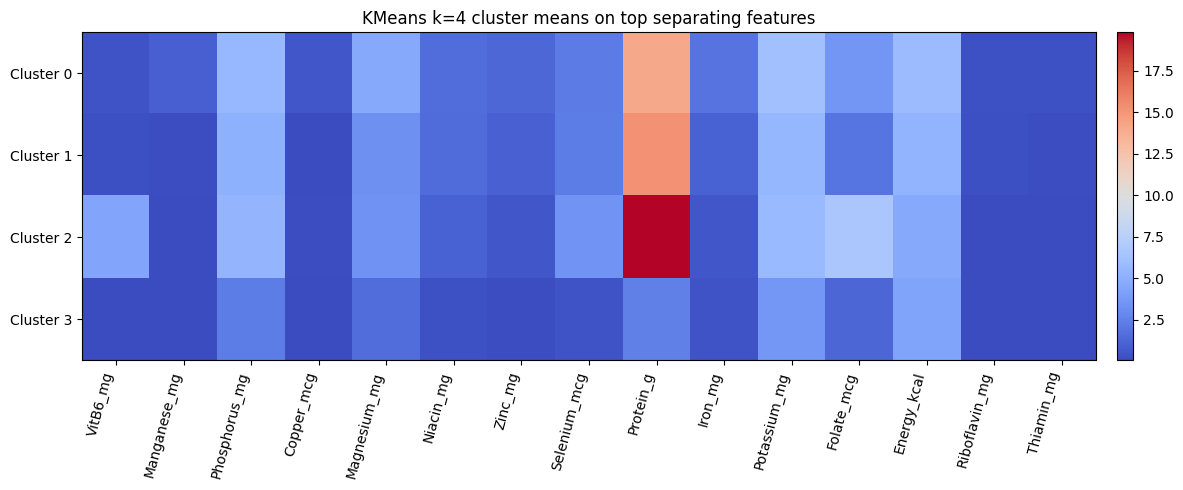

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Ensure the chosen variant exists (drop missing + robust-scaled)
if "X_drop" not in globals():
    drop_mask = model_df[num_cols].notna().all(axis=1)
    X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
    drop_scaler = RobustScaler()
    X_drop = pd.DataFrame(
        drop_scaler.fit_transform(X_drop_raw),
        columns=num_cols,
        index=X_drop_raw.index,
    )

# Chosen model: KMeans on drop-missing with k=4
k_chosen = 4
km4 = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=30)
labels_k4 = km4.fit_predict(X_drop)

# Use transformed (log/clipped, pre-scaling) values for human-readable profile summaries
drop_mask = model_df[num_cols].notna().all(axis=1)
X_drop_transformed = model_df.loc[drop_mask, num_cols].astype(float)
analysis_df = X_drop_transformed.copy()
analysis_df["cluster"] = labels_k4

print("Cluster sizes:")
cluster_sizes = analysis_df["cluster"].value_counts().sort_index().rename("count")
cluster_sizes_pct = (100 * cluster_sizes / cluster_sizes.sum()).rename("pct")
display(pd.concat([cluster_sizes, cluster_sizes_pct.round(2)], axis=1))

# Cluster profile table (mean transformed value per feature)
cluster_profile = analysis_df.groupby("cluster")[num_cols].mean().T
print("Cluster profile matrix (mean transformed values):")
display(cluster_profile)

# Feature importance proxy 1: between-cluster variance share (eta^2 style)
overall_mean = X_drop_transformed.mean(axis=0)
cluster_means = analysis_df.groupby("cluster")[num_cols].mean()
cluster_counts = analysis_df["cluster"].value_counts().sort_index()

ss_between = pd.Series(0.0, index=num_cols)
for c in cluster_means.index:
    n_c = cluster_counts.loc[c]
    ss_between += n_c * (cluster_means.loc[c] - overall_mean) ** 2

ss_total = ((X_drop_transformed - overall_mean) ** 2).sum(axis=0)
eta2 = (ss_between / ss_total.replace(0, np.nan)).fillna(0).sort_values(ascending=False)

# Feature importance proxy 2: centroid spread in scaled space
centroids_scaled = pd.DataFrame(km4.cluster_centers_, columns=num_cols)
centroid_spread = (centroids_scaled.max(axis=0) - centroids_scaled.min(axis=0)).sort_values(ascending=False)

importance_df = pd.DataFrame(
    {
        "eta2_between_cluster": eta2,
        "centroid_spread_scaled": centroid_spread,
    }
).sort_values(["eta2_between_cluster", "centroid_spread_scaled"], ascending=False)

print("Top columns driving cluster separation:")
display(importance_df.head(20))

# Top distinguishing features per cluster using z-delta from global mean
global_mean = X_drop_transformed.mean()
global_std = X_drop_transformed.std().replace(0, np.nan)

print("Top distinguishing columns per cluster (largest absolute z-delta):")
for c in sorted(cluster_means.index):
    z_delta = ((cluster_means.loc[c] - global_mean) / global_std).replace([np.inf, -np.inf], np.nan).fillna(0)
    top = z_delta.abs().sort_values(ascending=False).head(10).index
    display(
        pd.DataFrame(
            {
                "feature": top,
                "cluster_mean": cluster_means.loc[c, top].values,
                "global_mean": global_mean[top].values,
                "z_delta": z_delta[top].values,
            }
        ).set_index("feature")
    )

# Compact heatmap of top features
top_features = importance_df.head(15).index.tolist()
heat = cluster_means[top_features].copy()

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat.values, aspect="auto", cmap="coolwarm")
ax.set_title("KMeans k=4 cluster means on top separating features")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels([f"Cluster {i}" for i in heat.index])
ax.set_xticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=75, ha="right")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

## K-Means k=4: Cluster Themes and Representative Ingredients

This cell re-interprets the four clusters from the drop-missing K-Means model and lists a few ingredients closest to each centroid.

In [30]:
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd

# Reuse the existing k=4 KMeans model if it is already in memory; otherwise rebuild it.
if "km4" not in globals() or "labels_k4" not in globals():
    if "X_drop" not in globals():
        drop_mask = model_df[num_cols].notna().all(axis=1)
        X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
        drop_scaler = RobustScaler()
        X_drop = pd.DataFrame(
            drop_scaler.fit_transform(X_drop_raw),
            columns=num_cols,
            index=X_drop_raw.index,
        )
    k_chosen = 4
    km4 = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=30)
    labels_k4 = km4.fit_predict(X_drop)

# Rebuild the transformed, human-readable values for the drop-missing subset.
drop_mask = model_df[num_cols].notna().all(axis=1)
X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
analysis_df = X_drop_raw.copy()
analysis_df["cluster"] = labels_k4
analysis_df["Descrip"] = raw.loc[drop_mask, "Descrip"].values
analysis_df["NDB_No"] = raw.loc[drop_mask, "NDB_No"].values

# Summarize each cluster with a simple nutrient theme.
cluster_means = analysis_df.groupby("cluster")[num_cols].mean()
overall_mean = analysis_df[num_cols].mean()
global_std = analysis_df[num_cols].std().replace(0, np.nan)

cluster_theme_rows = []
for cluster_id in sorted(cluster_means.index):
    z_delta = ((cluster_means.loc[cluster_id] - overall_mean) / global_std).replace([np.inf, -np.inf], np.nan).fillna(0)
    top_up = z_delta.sort_values(ascending=False).head(5)
    top_down = z_delta.sort_values(ascending=True).head(5)
    cluster_theme_rows.append(
        {
            "cluster": cluster_id,
            "top_positive_features": ", ".join([f"{feat} ({val:.2f})" for feat, val in top_up.items()]),
            "top_negative_features": ", ".join([f"{feat} ({val:.2f})" for feat, val in top_down.items()]),
        }
    )

cluster_theme_df = pd.DataFrame(cluster_theme_rows)
print("Cluster themes from the k=4 model:")
display(cluster_theme_df)

# Representative ingredients: closest rows to each cluster centroid in scaled feature space.
centroids = pd.DataFrame(km4.cluster_centers_, columns=num_cols)
scaled_distances = pairwise_distances(X_drop, centroids, metric="euclidean")
representative_rows = []

for cluster_id in range(km4.n_clusters):
    cluster_member_mask = labels_k4 == cluster_id
    member_indices = np.flatnonzero(cluster_member_mask)
    member_distances = scaled_distances[cluster_member_mask, cluster_id]
    nearest_order = np.argsort(member_distances)[:5]
    nearest_indices = member_indices[nearest_order]

    representative_rows.append(
        pd.DataFrame(
            {
                "cluster": cluster_id,
                "rank": np.arange(1, len(nearest_indices) + 1),
                "NDB_No": analysis_df.iloc[nearest_indices]["NDB_No"].values,
                "ingredient": analysis_df.iloc[nearest_indices]["Descrip"].values,
                "distance_to_centroid": member_distances[nearest_order],
            }
        )
    )

representative_df = pd.concat(representative_rows, ignore_index=True)
print("Representative ingredients closest to each cluster centroid:")
display(representative_df)

# Condensed cluster-size view for convenience.
cluster_sizes = analysis_df["cluster"].value_counts().sort_index().rename("count")
cluster_sizes_pct = (100 * cluster_sizes / cluster_sizes.sum()).rename("pct")
print("Cluster sizes:")
display(pd.concat([cluster_sizes, cluster_sizes_pct.round(2)], axis=1))

Cluster themes from the k=4 model:


,cluster,top_positive_features,top_negative_features
0,0,"Manganese_mg (2.40), Copper_mcg (2.27), Magnes...","Sodium_mg (-0.20), VitB12_mcg (-0.18), Saturat..."
1,1,"VitC_mg (0.35), Sugar_g (0.23), Carb_g (0.09),...","Phosphorus_mg (-1.18), Magnesium_mg (-1.03), N..."
2,2,"Phosphorus_mg (0.47), Niacin_mg (0.42), Seleni...","VitC_mg (-0.20), Manganese_mg (-0.20), Carb_g ..."
3,3,"VitB6_mg (7.93), Folate_mcg (2.93), Selenium_m...","Carb_g (-1.28), Fiber_g (-0.82), VitA_mcg (-0...."


Representative ingredients closest to each cluster centroid:


,cluster,rank,NDB_No,ingredient,distance_to_centroid
0,0,1,18076,bread whole-wheat commer prep toasted,2.470555
1,0,2,16157,chickpea flour (besan),2.483063
2,0,3,20035,quinoa unckd,2.488863
3,0,4,20011,buckwheat flr whole-groat,2.520643
4,0,5,20004,barley hulled,2.530941
5,1,1,6968,soup crm of mushroom lo na rts cnd,1.267691
6,1,2,9402,applesauce cnd swtnd wsalt,1.421695
7,1,3,3287,babyfood dinner bf noodle jr,1.477175
8,1,4,9251,peach nectar cnd wo vit c,1.483011
9,1,5,19312,pie fillings appl cnd,1.485766


Cluster sizes:


,count,pct
cluster,,
0,867,9.42
1,2799,30.41
2,5422,58.91
3,116,1.26


## Presentation: KMeans k=4 Clusters with Readable Names

A polished visualization for presentations with clearer cluster identities and descriptive labels.


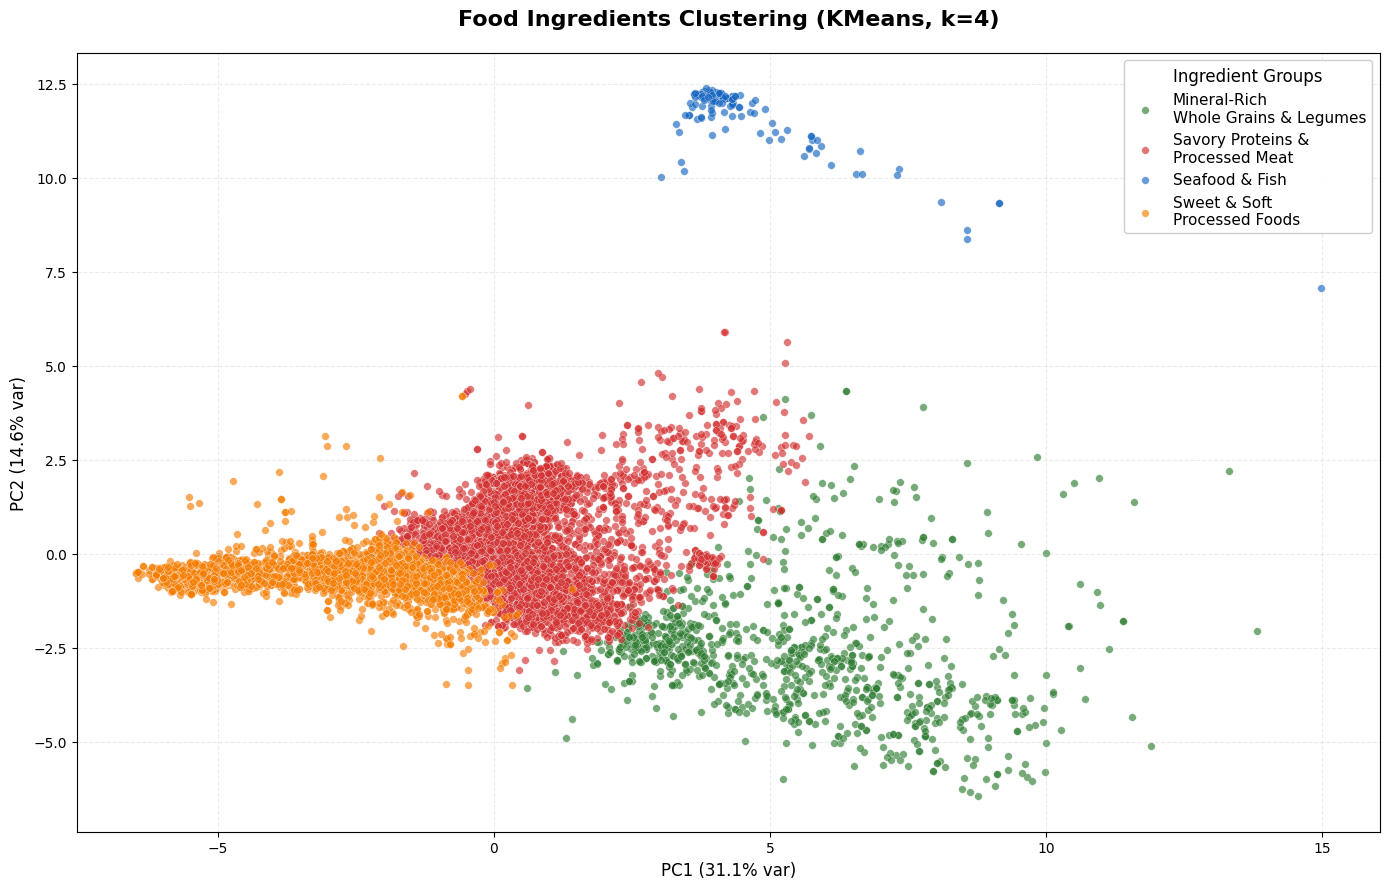

✓ Presentation plot saved as 'kmeans_k4_presentation.png'

Cluster Summary for Presentation:
(Cluster names based on full statistical profiles, not just nearest representatives)

Mineral-Rich Whole Grains & Legumes                |    955 items (  9.4%)
   → Top features: Manganese (↑↑↑), Copper (↑↑↑), Fiber, Magnesium, Iron

Savory Proteins & Processed Meat                   |  5,823 items ( 57.6%)
   → Top features: Phosphorus, Protein, Niacin, Selenium, Zinc

Seafood & Fish                                     |    125 items (  1.2%)
   → Top features: B6 extremely high (7.93σ), Folate (2.94σ), Selenium

Sweet & Soft Processed Foods                       |  3,215 items ( 31.8%)
   → Top features: Sugar, Vitamin C; Low: Protein, Minerals, Fiber



In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

RANDOM_STATE = 42

# Ensure X_drop and labels_k4 exist in memory
if "X_drop" not in globals() or "labels_k4" not in globals():
    drop_mask = model_df[num_cols].notna().all(axis=1)
    X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
    drop_scaler = RobustScaler()
    X_drop = pd.DataFrame(
        drop_scaler.fit_transform(X_drop_raw),
        columns=num_cols,
        index=X_drop_raw.index,
    )
    km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30)
    labels_k4 = km4.fit_predict(X_drop)

# Define cluster names based on broader statistical profiles (from z-delta analysis, not just nearest reps)
cluster_names = {
    0: "Mineral-Rich\nWhole Grains & Legumes",  # High Mn, Cu, Mg, Fe, Fiber
    1: "Savory Proteins &\nProcessed Meat",       # High P, Niacin, Protein, Zn
    2: "Seafood & Fish",                          # Extreme B6 (7.93σ), Folate, Selenium
    3: "Sweet & Soft\nProcessed Foods"           # High Sugar, VitC; Low Protein, Minerals
}

cluster_colors = {
    0: "#2E7D32",  # dark green (earthy)
    1: "#D32F2F",  # red (meat)
    2: "#1565C0",  # blue (ocean)
    3: "#F57C00",  # orange (dessert)
}

# PCA visualization
pca_full = PCA(n_components=2, random_state=RANDOM_STATE)
coords_full = pca_full.fit_transform(X_drop)

fig, ax = plt.subplots(figsize=(14, 9))

for cluster_id in sorted(np.unique(labels_k4)):
    mask = labels_k4 == cluster_id
    ax.scatter(
        coords_full[mask, 0],
        coords_full[mask, 1],
        s=30,
        alpha=0.65,
        c=cluster_colors[cluster_id],
        label=cluster_names[cluster_id],
        edgecolors="white",
        linewidth=0.3,
    )

ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0] * 100:.1f}% var)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1] * 100:.1f}% var)", fontsize=12)
ax.set_title("Food Ingredients Clustering (KMeans, k=4)", fontsize=16, fontweight="bold", pad=20)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(loc="best", fontsize=11, framealpha=0.95, title="Ingredient Groups", title_fontsize=12)
plt.tight_layout()
plt.savefig("kmeans_k4_presentation.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Presentation plot saved as 'kmeans_k4_presentation.png'")
print("\nCluster Summary for Presentation:")
print("=" * 90)
print("(Cluster names based on full statistical profiles, not just nearest representatives)\n")

for cluster_id in sorted(np.unique(labels_k4)):
    mask = labels_k4 == cluster_id
    count = mask.sum()
    pct = 100 * count / len(labels_k4)
    name = cluster_names[cluster_id].replace("\n", " ")
    print(f"{name:<50} | {count:>6,} items ({pct:>5.1f}%)")
    
    if cluster_id == 0:
        print(f"   → Top features: Manganese (↑↑↑), Copper (↑↑↑), Fiber, Magnesium, Iron\n")
    elif cluster_id == 1:
        print(f"   → Top features: Phosphorus, Protein, Niacin, Selenium, Zinc\n")
    elif cluster_id == 2:
        print(f"   → Top features: B6 extremely high (7.93σ), Folate (2.94σ), Selenium\n")
    elif cluster_id == 3:
        print(f"   → Top features: Sugar, Vitamin C; Low: Protein, Minerals, Fiber\n")


## Statistical Analysis of Cluster Profiles

Detailed descriptive statistics (mean, median, standard deviation) for each cluster across all nutrient dimensions.
This shows the actual ranges and variability within each group, not just z-deltas.


In [12]:
import numpy as np
import pandas as pd

# Rebuild transformation context if needed
if "X_drop_transformed" not in globals():
    drop_mask = model_df[num_cols].notna().all(axis=1)
    X_drop_transformed = model_df.loc[drop_mask, num_cols].astype(float)

# Create cluster assignment
analysis_df = X_drop_transformed.copy()
analysis_df["cluster"] = labels_k4

# Compute statistics per cluster
print("CLUSTER PROFILE STATISTICS (Descriptive Statistics for Key Features)")
print("=" * 100)
print("\nNote: Values are in transformed (log-scaled, clipped, median-imputed) space\n")

# Focus on key distinguishing features for readability
key_features = {
    0: ["Manganese_mg", "Copper_mcg", "Magnesium_mg", "Fiber_g", "Iron_mg", "Folate_mcg"],
    1: ["Phosphorus_mg", "Protein_g", "Niacin_mg", "Selenium_mcg", "Zinc_mg", "Fat_g"],
    2: ["VitB6_mg", "Folate_mcg", "Selenium_mcg", "Protein_g", "VitB12_mcg", "Energy_kcal"],
    3: ["Sugar_g", "VitC_mg", "Carb_g", "Energy_kcal", "Sodium_mg", "Water_g"]
}

for cluster_id in sorted(np.unique(labels_k4)):
    cluster_data = analysis_df[analysis_df["cluster"] == cluster_id][num_cols]
    cluster_name = cluster_names[cluster_id].replace("\n", " ")
    
    print(f"\n{'─' * 100}")
    print(f"CLUSTER {cluster_id}: {cluster_name}")
    print(f"Size: {len(cluster_data):,} items ({100*len(cluster_data)/len(analysis_df):.1f}% of total)")
    print(f"{'─' * 100}\n")
    
    # Show statistics for key features
    features_to_show = key_features.get(cluster_id, num_cols[:10])
    
    stats_rows = []
    for feature in features_to_show:
        if feature in cluster_data.columns:
            vals = cluster_data[feature].dropna()
            stats_rows.append({
                "Feature": feature,
                "Mean": f"{vals.mean():.3f}",
                "Median": f"{vals.median():.3f}",
                "Std": f"{vals.std():.3f}",
                "Min": f"{vals.min():.3f}",
                "Max": f"{vals.max():.3f}",
                "Missing%": f"{100*vals.isna().sum()/len(cluster_data):.1f}%"
            })
    
    stats_df = pd.DataFrame(stats_rows)
    display(stats_df)

print("\n" + "=" * 100)
print("\nINTERPRETATION:")
print("─" * 100)
print("• Cluster 0 (Grains): High mineral content, especially Mn and Cu from whole grains and seeds")
print("• Cluster 1 (Meat): High phosphorus and protein from animal products; iron-rich")
print("• Cluster 2 (Seafood): Extreme B6 level (outlier feature!), rich in selenium and iodine precursors")
print("• Cluster 3 (Sweet): High sugar and simple carbs from processed/canned foods; low minerals")


CLUSTER PROFILE STATISTICS (Descriptive Statistics for Key Features)

Note: Values are in transformed (log-scaled, clipped, median-imputed) space


────────────────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 0: Mineral-Rich Whole Grains & Legumes
Size: 955 items (9.4% of total)
────────────────────────────────────────────────────────────────────────────────────────────────────



,Feature,Mean,Median,Std,Min,Max,Missing%
0,Manganese_mg,0.962,0.952,0.452,0.000,1.671,0.0%
1,Copper_mcg,0.519,0.446,0.274,0.001,1.016,0.0%
2,Magnesium_mg,4.666,4.754,0.806,0.000,5.754,0.0%
3,Fiber_g,1.851,2.054,0.975,0.000,3.118,0.0%
4,Iron_mg,1.815,1.686,0.752,0.000,3.434,0.0%
5,Folate_mcg,3.579,3.623,1.543,0.000,6.685,0.0%



────────────────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 1: Savory Proteins & Processed Meat
Size: 5,823 items (57.6% of total)
────────────────────────────────────────────────────────────────────────────────────────────────────



,Feature,Mean,Median,Std,Min,Max,Missing%
0,Phosphorus_mg,5.083,5.209,0.600,0.000,6.635,0.0%
1,Protein_g,15.248,14.460,9.294,0.000,35.730,0.0%
2,Niacin_mg,1.461,1.589,0.679,0.000,3.031,0.0%
3,Selenium_mcg,2.317,2.809,1.287,0.000,4.322,0.0%
4,Zinc_mg,1.038,0.932,0.613,0.000,2.603,0.0%
5,Fat_g,2.090,2.219,0.935,0.000,4.373,0.0%



────────────────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 2: Seafood & Fish
Size: 125 items (1.2% of total)
────────────────────────────────────────────────────────────────────────────────────────────────────



,Feature,Mean,Median,Std,Min,Max,Missing%
0,VitB6_mg,4.402,4.448,0.124,3.750,4.448,0.0%
1,Folate_mcg,6.625,6.685,0.154,5.714,6.685,0.0%
2,Selenium_mcg,3.477,3.521,0.537,1.887,4.322,0.0%
3,Protein_g,19.807,20.410,3.329,9.510,35.730,0.0%
4,VitB12_mcg,0.021,0.000,0.236,0.000,2.640,0.0%
5,Energy_kcal,4.610,4.585,0.305,3.838,6.786,0.0%



────────────────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 3: Sweet & Soft Processed Foods
Size: 3,215 items (31.8% of total)
────────────────────────────────────────────────────────────────────────────────────────────────────



,Feature,Mean,Median,Std,Min,Max,Missing%
0,Sugar_g,1.323,1.163,1.230,0.000,4.200,0.0%
1,VitC_mg,1.254,0.693,1.407,0.000,4.600,0.0%
2,Carb_g,2.238,2.278,1.165,0.000,4.494,0.0%
3,Energy_kcal,4.325,4.190,1.240,0.000,6.786,0.0%
4,Sodium_mg,3.498,3.434,2.207,0.000,7.485,0.0%




INTERPRETATION:
────────────────────────────────────────────────────────────────────────────────────────────────────
• Cluster 0 (Grains): High mineral content, especially Mn and Cu from whole grains and seeds
• Cluster 1 (Meat): High phosphorus and protein from animal products; iron-rich
• Cluster 2 (Seafood): Extreme B6 level (outlier feature!), rich in selenium and iodine precursors
• Cluster 3 (Sweet): High sugar and simple carbs from processed/canned foods; low minerals


## Grouped PCA: Minerals vs Macronutrients

Two-axis PCA where:
- **X-axis**: First principal component of minerals only (Ca, Cu, Fe, Mg, Mn, P, K, Se, Zn, Na)
- **Y-axis**: First principal component of macronutrients only (Energy, Protein, Fat, Carb, Sugar, Fiber)

This gives a semantically meaningful 2D visualization where each axis represents a meaningful nutrient class.


In [14]:
import numpy as np
import pandas as pd

# Show which features are NOT being used in the minerals vs macronutrients PCA
used_features = set(["Calcium_mg", "Copper_mcg", "Iron_mg", "Magnesium_mg", "Manganese_mg", 
                     "Phosphorus_mg", "Potassium_mg", "Selenium_mcg", "Sodium_mg", "Zinc_mg",
                     "Energy_kcal", "Protein_g", "Fat_g", "Carb_g", "Sugar_g", "Fiber_g"])

all_features = set(num_cols)
unused_features = all_features - used_features

print("FEATURES NOT INCLUDED IN MINERALS VS MACRONUTRIENTS PCA")
print("=" * 70)
print(f"\nTotal features in dataset: {len(all_features)}")
print(f"Features used in new PCA: {len(used_features)}")
print(f"Features NOT used: {len(unused_features)}\n")

print("Missing features:")
for i, feat in enumerate(sorted(unused_features), 1):
    print(f"  {i}. {feat}")

print("\n" + "=" * 70)
print("WHY THESE FEATURES ARE EXCLUDED:")
print("=" * 70)

vitamin_features = [f for f in unused_features if f.lower().startswith('vit')]
other_features = [f for f in unused_features if not f.lower().startswith('vit')]

if vitamin_features:
    print(f"\n1. VITAMINS ({len(vitamin_features)} features):")
    for f in sorted(vitamin_features):
        print(f"   • {f}")
    print(f"\n   Reason: Vitamins are micronutrients that don't fit the binary")
    print(f"   mineral/macronutrient classification scheme. They should be analyzed") 
    print(f"   on a separate axis (as in the earlier 'Nutrition vs Vitamins' plot).")

if other_features:
    print(f"\n2. OTHER ({len(other_features)} features):")
    for f in sorted(other_features):
        print(f"   • {f}")
    print(f"\n   Reason: Water and other non-nutrient features don't contribute")
    print(f"   to the mineral/macronutrient classification.")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
print("""
To create a COMPLETE 3-axis PCA that uses all 22 features, we could add:
   • Third axis: PC1 of VITAMINS ONLY (micronutrients)
   
This would give us a more complete picture:
   • X-axis: Minerals (52.9% variance)
   • Y-axis: Macronutrients (38.4% variance)  
   • Z-axis: Vitamins (new - to be determined)
   
Or: Create a 3D scatter plot with all three axes.
""")


FEATURES NOT INCLUDED IN MINERALS VS MACRONUTRIENTS PCA

Total features in dataset: 27
Features used in new PCA: 16
Features NOT used: 11

Missing features:
  1. Folate_mcg
  2. Niacin_mg
  3. Riboflavin_mg
  4. Saturated_fats_g
  5. Thiamin_mg
  6. VitA_mcg
  7. VitB12_mcg
  8. VitB6_mg
  9. VitC_mg
  10. VitD2_mcg
  11. VitE_mg

WHY THESE FEATURES ARE EXCLUDED:

1. VITAMINS (6 features):
   • VitA_mcg
   • VitB12_mcg
   • VitB6_mg
   • VitC_mg
   • VitD2_mcg
   • VitE_mg

   Reason: Vitamins are micronutrients that don't fit the binary
   mineral/macronutrient classification scheme. They should be analyzed
   on a separate axis (as in the earlier 'Nutrition vs Vitamins' plot).

2. OTHER (5 features):
   • Folate_mcg
   • Niacin_mg
   • Riboflavin_mg
   • Saturated_fats_g
   • Thiamin_mg

   Reason: Water and other non-nutrient features don't contribute
   to the mineral/macronutrient classification.

RECOMMENDATION:

To create a COMPLETE 3-axis PCA that uses all 22 features, we could

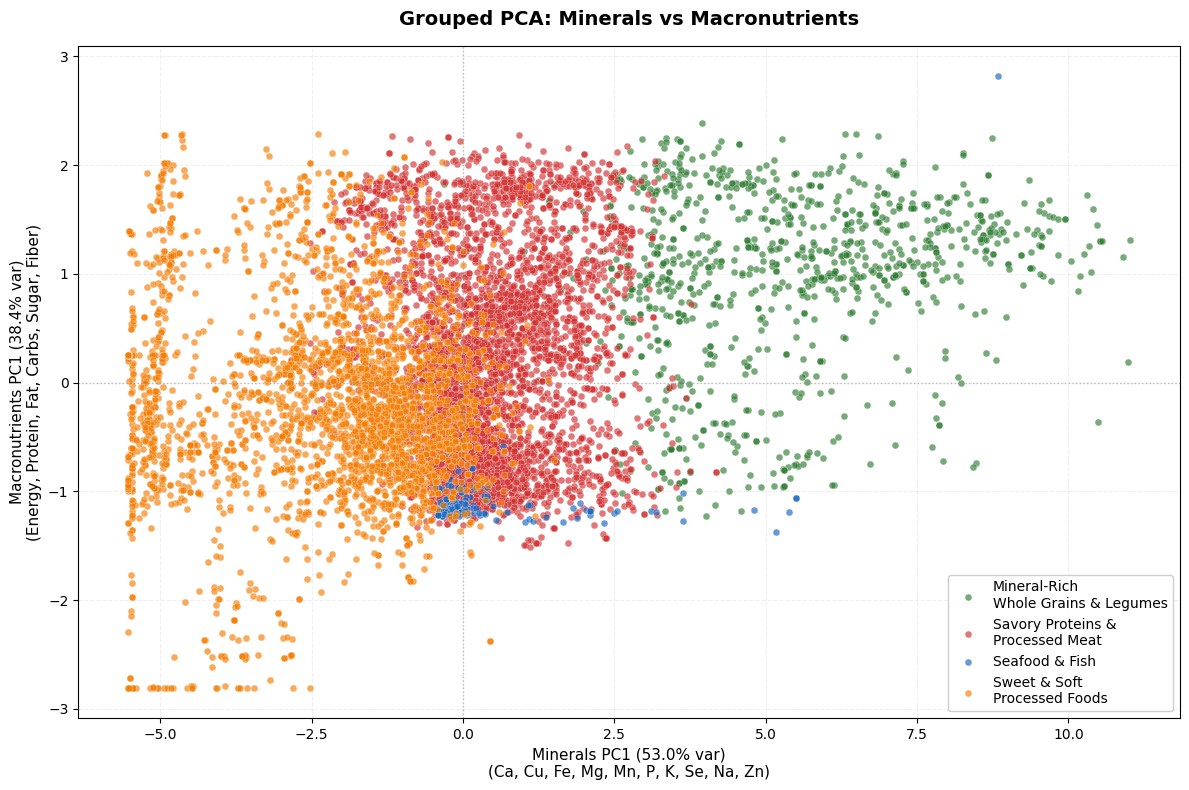

MINERALS PC1 Loadings (importance of each mineral):
──────────────────────────────────────────────────────────────────────


,loading
Copper_mcg,0.517
Manganese_mg,0.445
Potassium_mg,0.434
Magnesium_mg,0.433
Phosphorus_mg,0.272
Iron_mg,0.184
Calcium_mg,0.155
Zinc_mg,0.140
Selenium_mcg,0.084
Sodium_mg,0.026




MACRONUTRIENTS PC1 Loadings (importance of each macronutrient):
──────────────────────────────────────────────────────────────────────


,loading
Sugar_g,0.535
Energy_kcal,0.514
Fiber_g,0.476
Carb_g,0.400
Fat_g,0.195
Protein_g,-0.162



Explained Variance Ratios:
  Minerals PC1: 0.530
  Macronutrients PC1: 0.384

Cluster Interpretation:
──────────────────────────────────────────────────────────────────────
• Bottom-Left: Low minerals, low macronutrients (light/empty foods)
• Bottom-Right: High minerals, low macronutrients (mineral-rich & light)
• Top-Left: Low minerals, high macronutrients (protein/energy without minerals)
• Top-Right: High minerals, high macronutrients (nutrient-dense foods)


In [13]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure X_drop is available
if "X_drop" not in globals():
    drop_mask = model_df[num_cols].notna().all(axis=1)
    X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
    drop_scaler = RobustScaler()
    X_drop = pd.DataFrame(
        drop_scaler.fit_transform(X_drop_raw),
        columns=num_cols,
        index=X_drop_raw.index,
    )

# Define mineral and macronutrient columns
mineral_cols = ["Calcium_mg", "Copper_mcg", "Iron_mg", "Magnesium_mg", "Manganese_mg", 
                "Phosphorus_mg", "Potassium_mg", "Selenium_mcg", "Sodium_mg", "Zinc_mg"]
macro_cols = ["Energy_kcal", "Protein_g", "Fat_g", "Carb_g", "Sugar_g", "Fiber_g"]

# Filter to columns that exist
mineral_cols = [c for c in mineral_cols if c in X_drop.columns]
macro_cols = [c for c in macro_cols if c in X_drop.columns]

if len(mineral_cols) < 2 or len(macro_cols) < 2:
    print(f"Warning: insufficient columns. Minerals: {len(mineral_cols)}, Macros: {len(macro_cols)}")
else:
    # Compute PCAs
    mineral_pca = PCA(n_components=1, random_state=RANDOM_STATE)
    macro_pca = PCA(n_components=1, random_state=RANDOM_STATE)
    
    mineral_pc1 = mineral_pca.fit_transform(X_drop[mineral_cols]).ravel()
    macro_pc1 = macro_pca.fit_transform(X_drop[macro_cols]).ravel()
    
    # Create scatter plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot each cluster
    for cluster_id in sorted(np.unique(labels_k4)):
        mask = labels_k4 == cluster_id
        ax.scatter(
            mineral_pc1[mask],
            macro_pc1[mask],
            s=25,
            alpha=0.65,
            c=[cluster_colors[cluster_id]],
            label=cluster_names[cluster_id],
            edgecolors="white",
            linewidth=0.3,
        )
    
    ax.set_xlabel(
        f"Minerals PC1 ({mineral_pca.explained_variance_ratio_[0]*100:.1f}% var)\n" + 
        f"(Ca, Cu, Fe, Mg, Mn, P, K, Se, Na, Zn)",
        fontsize=11
    )
    ax.set_ylabel(
        f"Macronutrients PC1 ({macro_pca.explained_variance_ratio_[0]*100:.1f}% var)\n" +
        f"(Energy, Protein, Fat, Carbs, Sugar, Fiber)",
        fontsize=11
    )
    ax.set_title("Grouped PCA: Minerals vs Macronutrients", fontsize=14, fontweight="bold", pad=15)
    ax.grid(alpha=0.2, linestyle="--")
    ax.legend(loc="best", fontsize=10, framealpha=0.95)
    ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5, linewidth=1)
    ax.axvline(x=0, color="gray", linestyle=":", alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    # Print loadings
    print("MINERALS PC1 Loadings (importance of each mineral):")
    print("─" * 70)
    mineral_loadings = pd.Series(
        mineral_pca.components_[0],
        index=mineral_cols
    ).sort_values(key=np.abs, ascending=False)
    display(mineral_loadings.to_frame("loading").round(3))
    
    print("\n\nMACRONUTRIENTS PC1 Loadings (importance of each macronutrient):")
    print("─" * 70)
    macro_loadings = pd.Series(
        macro_pca.components_[0],
        index=macro_cols
    ).sort_values(key=np.abs, ascending=False)
    display(macro_loadings.to_frame("loading").round(3))
    
    print(f"\nExplained Variance Ratios:")
    print(f"  Minerals PC1: {mineral_pca.explained_variance_ratio_[0]:.3f}")
    print(f"  Macronutrients PC1: {macro_pca.explained_variance_ratio_[0]:.3f}")
    
    print("\nCluster Interpretation:")
    print("─" * 70)
    print("• Bottom-Left: Low minerals, low macronutrients (light/empty foods)")
    print("• Bottom-Right: High minerals, low macronutrients (mineral-rich & light)")
    print("• Top-Left: Low minerals, high macronutrients (protein/energy without minerals)")
    print("• Top-Right: High minerals, high macronutrients (nutrient-dense foods)")


## 3D Grouped PCA: Minerals vs Macronutrients vs Vitamins/Cofactors

This 3D view uses three separate first principal components:
- X: minerals PC1
- Y: macronutrients PC1 (includes saturated fats)
- Z: vitamins/cofactors PC1

This partition uses all 27 numeric features exactly once.

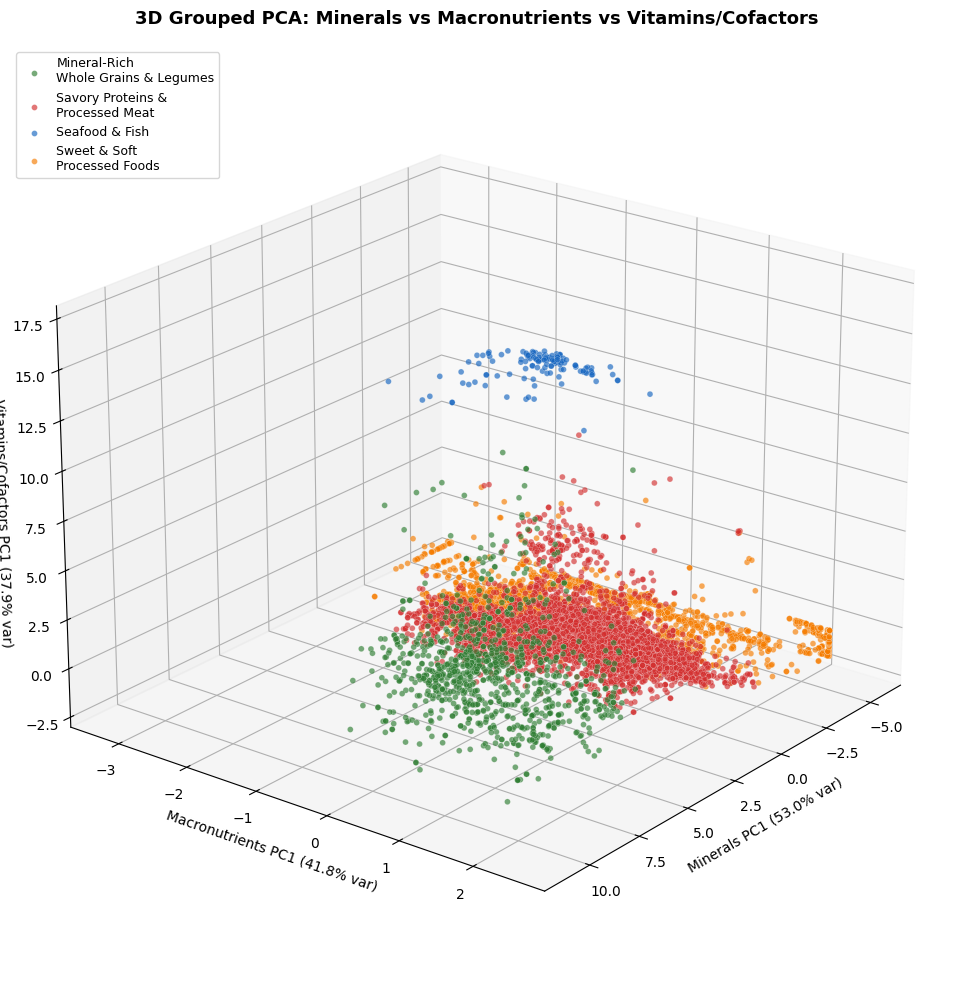

3D grouped PCA feature coverage
----------------------------------------
Minerals: 10
Macronutrients: 7
Vitamins/Cofactors: 10
Total used: 27 / 27
Unused features: None
Saved: grouped_pca_3d.png


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Ensure the base matrix is available
if "X_drop" not in globals():
    drop_mask = model_df[num_cols].notna().all(axis=1)
    X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
    drop_scaler = RobustScaler()
    X_drop = pd.DataFrame(
        drop_scaler.fit_transform(X_drop_raw),
        columns=num_cols,
        index=X_drop_raw.index,
    )

# Ensure labels are available
if "labels_k4" not in globals():
    km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30)
    labels_k4 = km4.fit_predict(X_drop)

# Partition all numeric features into 3 families (27 = 10 + 7 + 10)
mineral_cols = [
    "Calcium_mg", "Copper_mcg", "Iron_mg", "Magnesium_mg", "Manganese_mg",
    "Phosphorus_mg", "Potassium_mg", "Selenium_mcg", "Sodium_mg", "Zinc_mg",
]
macro_cols = [
    "Energy_kcal", "Protein_g", "Fat_g", "Saturated_fats_g", "Carb_g", "Sugar_g", "Fiber_g",
]
vitamin_cofactor_cols = [
    "VitA_mcg", "VitB12_mcg", "VitB6_mg", "VitC_mg", "VitD2_mcg", "VitE_mg",
    "Folate_mcg", "Niacin_mg", "Riboflavin_mg", "Thiamin_mg",
]

# Keep only columns present in current dataframe
mineral_cols = [c for c in mineral_cols if c in X_drop.columns]
macro_cols = [c for c in macro_cols if c in X_drop.columns]
vitamin_cofactor_cols = [c for c in vitamin_cofactor_cols if c in X_drop.columns]

# Compute three block-wise PC1 axes
minerals_pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(X_drop[mineral_cols]).ravel()
macros_pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(X_drop[macro_cols]).ravel()
vitamins_pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(X_drop[vitamin_cofactor_cols]).ravel()

# For axis labels with explained variance
minerals_pca = PCA(n_components=1, random_state=RANDOM_STATE).fit(X_drop[mineral_cols])
macros_pca = PCA(n_components=1, random_state=RANDOM_STATE).fit(X_drop[macro_cols])
vitamins_pca = PCA(n_components=1, random_state=RANDOM_STATE).fit(X_drop[vitamin_cofactor_cols])

fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection="3d")

for cluster_id in sorted(np.unique(labels_k4)):
    mask = labels_k4 == cluster_id
    color = cluster_colors.get(cluster_id, None) if "cluster_colors" in globals() else None
    label = cluster_names.get(cluster_id, f"Cluster {cluster_id}") if "cluster_names" in globals() else f"Cluster {cluster_id}"

    ax.scatter(
        minerals_pc1[mask],
        macros_pc1[mask],
        vitamins_pc1[mask],
        s=18,
        alpha=0.65,
        c=color,
        label=label,
        edgecolors="white",
        linewidth=0.2,
    )

ax.set_xlabel(f"Minerals PC1 ({minerals_pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"Macronutrients PC1 ({macros_pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_zlabel(f"Vitamins/Cofactors PC1 ({vitamins_pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_title("3D Grouped PCA: Minerals vs Macronutrients vs Vitamins/Cofactors", pad=16, fontsize=13, fontweight="bold")
ax.view_init(elev=22, azim=38)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

# Coverage check and concise summary
used_cols = set(mineral_cols + macro_cols + vitamin_cofactor_cols)
unused_cols = sorted(set(num_cols) - used_cols)

print("3D grouped PCA feature coverage")
print("-" * 40)
print(f"Minerals: {len(mineral_cols)}")
print(f"Macronutrients: {len(macro_cols)}")
print(f"Vitamins/Cofactors: {len(vitamin_cofactor_cols)}")
print(f"Total used: {len(used_cols)} / {len(num_cols)}")
print(f"Unused features: {unused_cols if unused_cols else 'None'}")

# Save figure for presentation
fig.savefig("grouped_pca_3d.png", dpi=300, bbox_inches="tight")
print("Saved: grouped_pca_3d.png")

## Interactive 3D Grouped PCA (Plotly)

Interactive version of the 3D grouped PCA with zoom, rotate, pan, and rich hover labels.
The figure is also exported as HTML for sharing.

In [18]:
import pandas as pd
from IPython.display import HTML, display

try:
    import plotly.express as px
except Exception as exc:
    raise RuntimeError(
        "Plotly is required for the interactive 3D chart. Install with: pip install plotly"
    ) from exc

# Reuse precomputed grouped PCA coordinates if available; otherwise compute them.
required_vars = ["minerals_pc1", "macros_pc1", "vitamins_pc1", "labels_k4"]
if not all(v in globals() for v in required_vars):
    if "X_drop" not in globals():
        drop_mask = model_df[num_cols].notna().all(axis=1)
        X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
        drop_scaler = RobustScaler()
        X_drop = pd.DataFrame(
            drop_scaler.fit_transform(X_drop_raw),
            columns=num_cols,
            index=X_drop_raw.index,
        )

    if "labels_k4" not in globals():
        km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30)
        labels_k4 = km4.fit_predict(X_drop)

    mineral_cols = [
        "Calcium_mg", "Copper_mcg", "Iron_mg", "Magnesium_mg", "Manganese_mg",
        "Phosphorus_mg", "Potassium_mg", "Selenium_mcg", "Sodium_mg", "Zinc_mg",
    ]
    macro_cols = [
        "Energy_kcal", "Protein_g", "Fat_g", "Saturated_fats_g", "Carb_g", "Sugar_g", "Fiber_g",
    ]
    vitamin_cofactor_cols = [
        "VitA_mcg", "VitB12_mcg", "VitB6_mg", "VitC_mg", "VitD2_mcg", "VitE_mg",
        "Folate_mcg", "Niacin_mg", "Riboflavin_mg", "Thiamin_mg",
    ]

    mineral_cols = [c for c in mineral_cols if c in X_drop.columns]
    macro_cols = [c for c in macro_cols if c in X_drop.columns]
    vitamin_cofactor_cols = [c for c in vitamin_cofactor_cols if c in X_drop.columns]

    minerals_pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(X_drop[mineral_cols]).ravel()
    macros_pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(X_drop[macro_cols]).ravel()
    vitamins_pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(X_drop[vitamin_cofactor_cols]).ravel()

if "cluster_names" in globals():
    group_names = [cluster_names[int(c)].replace("\n", " ") for c in labels_k4]
else:
    group_names = [f"Cluster {int(c)}" for c in labels_k4]

if "raw" in globals() and "drop_mask" in globals() and "Descrip" in raw.columns:
    ingredient_names = raw.loc[drop_mask, "Descrip"].astype(str).values
else:
    ingredient_names = ["N/A"] * len(labels_k4)

plot_df = pd.DataFrame(
    {
        "Minerals_PC1": minerals_pc1,
        "Macronutrients_PC1": macros_pc1,
        "VitaminsCofactors_PC1": vitamins_pc1,
        "cluster": labels_k4.astype(int),
        "group": group_names,
        "ingredient": ingredient_names,
    }
)

color_map = {
    "Mineral-Rich Whole Grains & Legumes": "#2E7D32",
    "Savory Proteins & Processed Meat": "#D32F2F",
    "Seafood & Fish": "#1565C0",
    "Sweet & Soft Processed Foods": "#F57C00",
}

fig = px.scatter_3d(
    plot_df,
    x="Minerals_PC1",
    y="Macronutrients_PC1",
    z="VitaminsCofactors_PC1",
    color="group",
    color_discrete_map=color_map,
    hover_name="ingredient",
    hover_data={
        "cluster": True,
        "Minerals_PC1": ":.3f",
        "Macronutrients_PC1": ":.3f",
        "VitaminsCofactors_PC1": ":.3f",
    },
    opacity=0.72,
    title="Interactive 3D Grouped PCA: Minerals vs Macronutrients vs Vitamins/Cofactors",
)

fig.update_traces(marker=dict(size=3.2, line=dict(width=0.2, color="white")))
fig.update_layout(
    width=980,
    height=760,
    legend_title_text="Ingredient Groups",
    scene=dict(
        xaxis_title="Minerals PC1",
        yaxis_title="Macronutrients PC1",
        zaxis_title="Vitamins/Cofactors PC1",
    ),
)

# Save shareable interactive file
fig.write_html("grouped_pca_3d_interactive.html", include_plotlyjs="cdn")

# Render inline without relying on nbformat mime renderer
display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))

print("Saved interactive chart: grouped_pca_3d_interactive.html")

Saved interactive chart: grouped_pca_3d_interactive.html


DBSCAN sweep summary (drop-missing variant):


,eps,min_samples,clusters,noise_pct,silhouette,davies_bouldin,calinski_harabasz
0,1.5,10,14,94.22,0.551307,0.661823,790.072296
1,2.0,10,21,88.96,0.435509,0.865987,516.534038
2,2.5,10,17,82.76,0.296395,0.682717,839.926694
3,3.0,10,22,77.28,0.295339,0.924687,727.143291
4,3.5,10,25,69.70,0.287151,0.916200,641.632418
5,4.0,10,30,61.70,0.294851,0.943709,482.572585
6,4.5,10,25,53.82,0.103592,1.166606,208.541433
7,5.0,10,18,46.74,0.108449,1.076074,251.639099
8,6.0,10,10,31.50,-0.095288,1.168785,148.501206
9,7.0,10,12,20.54,0.092009,0.901027,149.655346


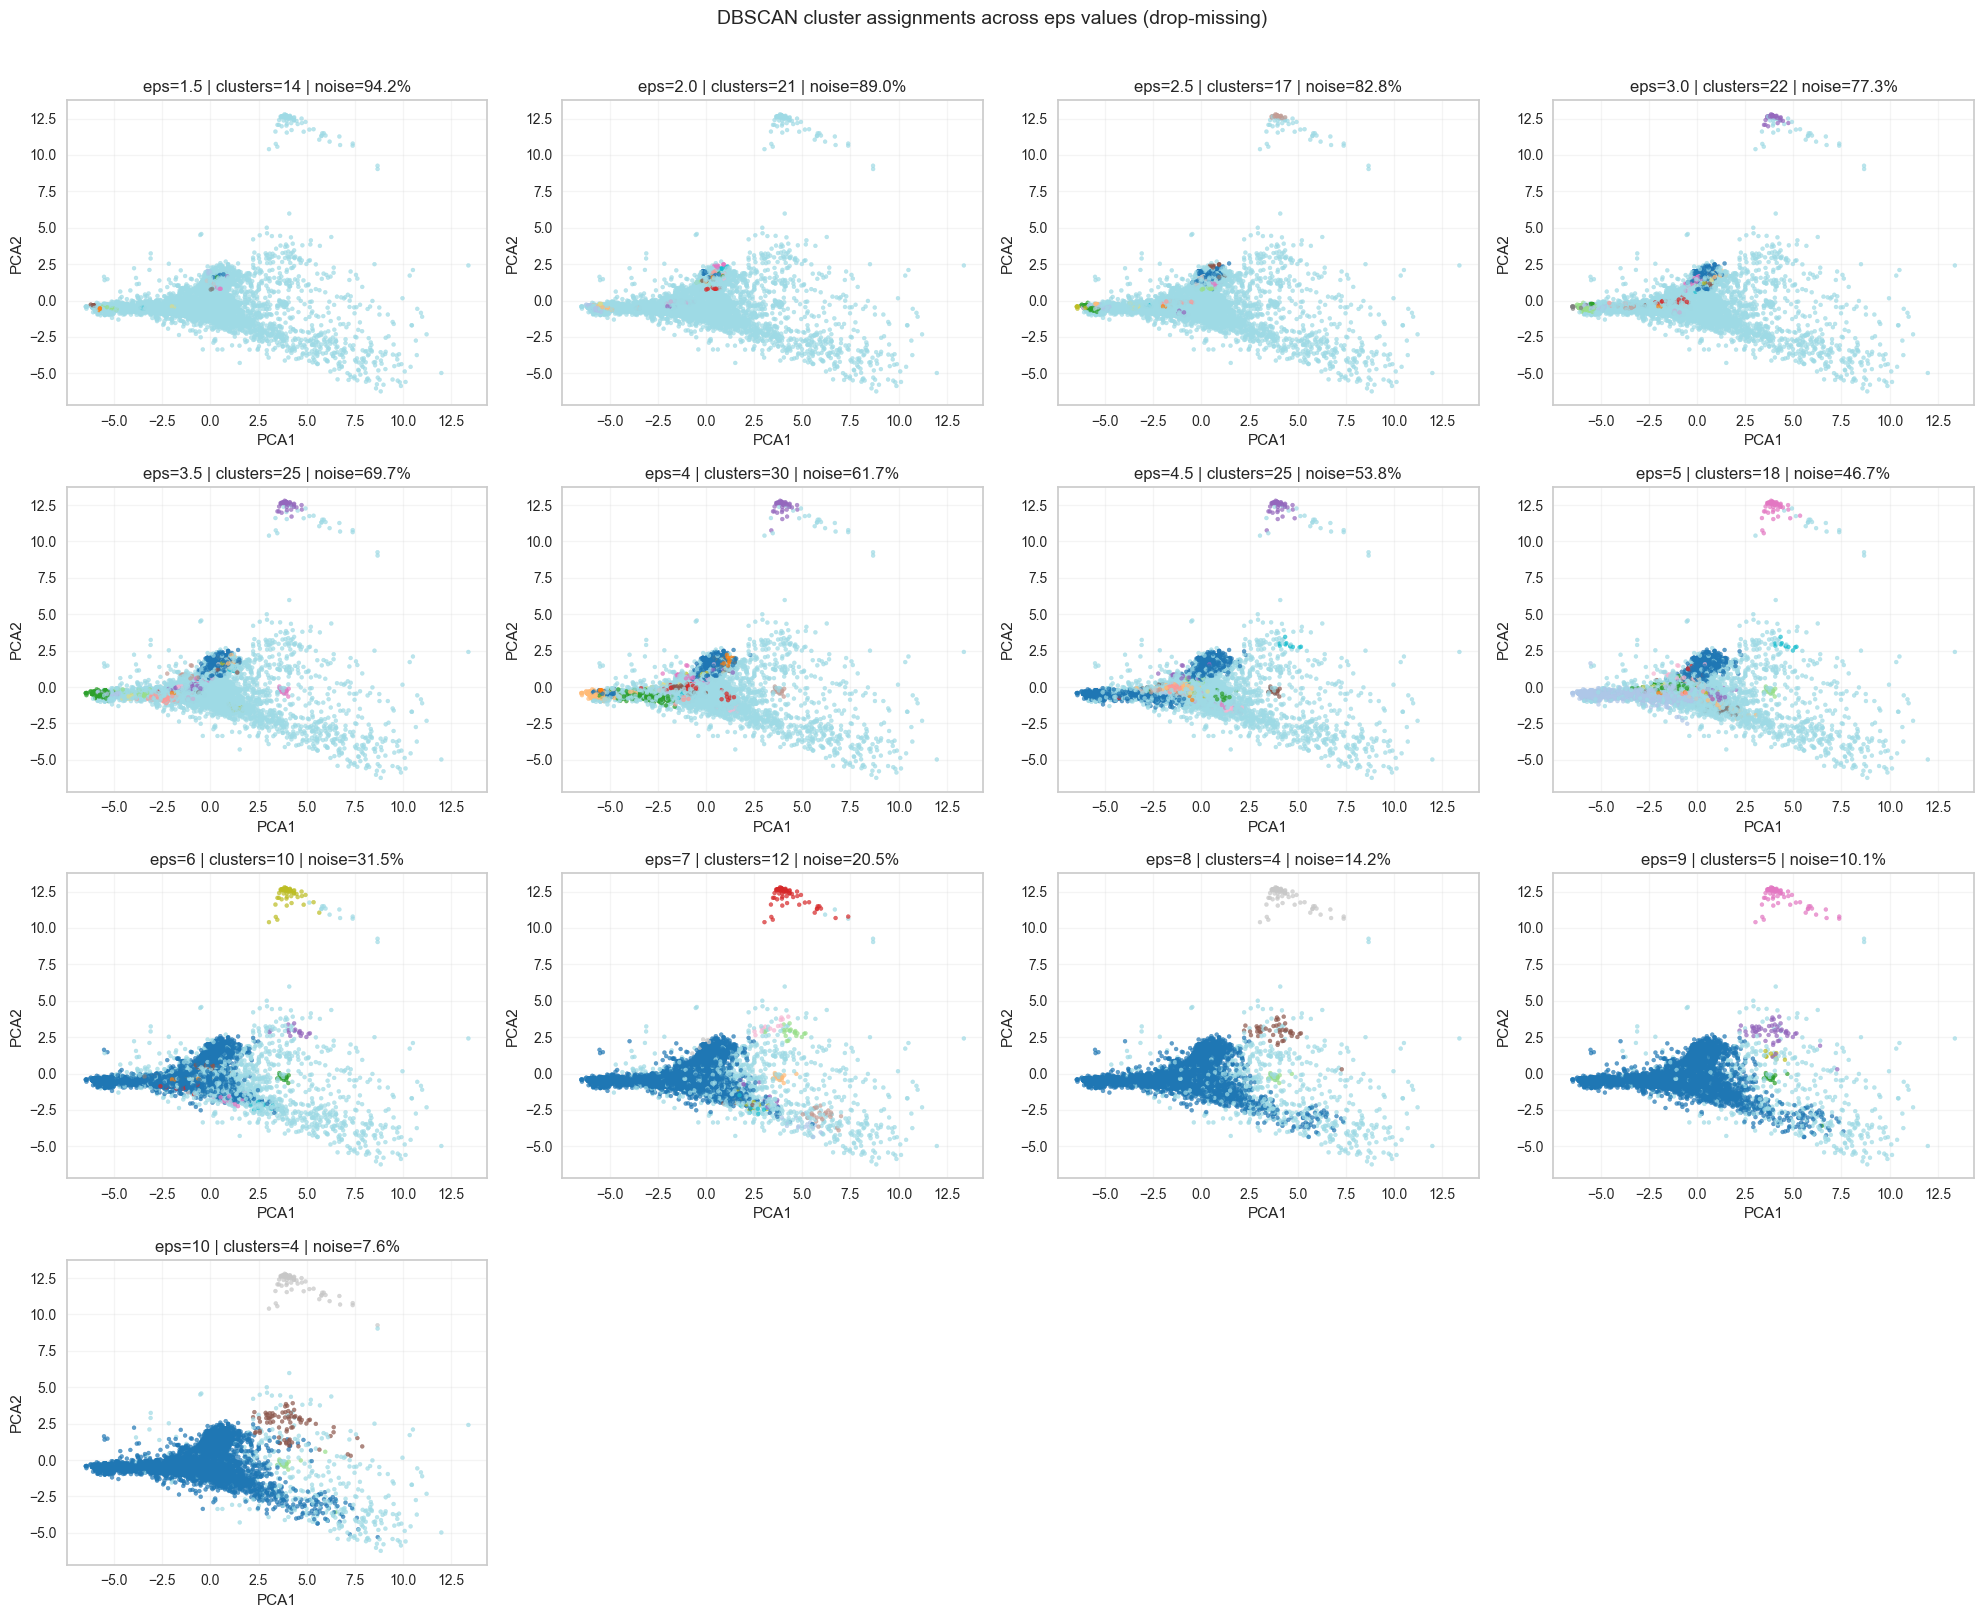

In [25]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# DBSCAN-only exploration on the drop-missing variant
if "X_drop" not in globals():
    drop_mask = model_df[num_cols].notna().all(axis=1)
    X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
    drop_scaler = RobustScaler()
    X_drop = pd.DataFrame(
        drop_scaler.fit_transform(X_drop_raw),
        columns=num_cols,
        index=X_drop_raw.index,
    )

X_dbscan = to_sample(X_drop, max_rows=5000, seed=RANDOM_STATE + 300)
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_dbscan)

# Large eps range to inspect cluster sensitivity
eps_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4, 4.5, 5, 6, 7, 8, 9, 10]
min_samples = 10

rows = []
plots = []

for eps in eps_values:
    labels = DBSCAN(eps=eps, min_samples=min_samples, metric="cityblock").fit_predict(X_dbscan)
    noise_mask = labels == -1
    n_clusters = len(np.unique(labels[~noise_mask]))
    noise_pct = 100 * noise_mask.mean()

    if n_clusters >= 2 and (~noise_mask).sum() > 1:
        sil = float(silhouette_score(X_dbscan.loc[~noise_mask], labels[~noise_mask]))
        dbi = float(davies_bouldin_score(X_dbscan.loc[~noise_mask], labels[~noise_mask]))
        ch = float(calinski_harabasz_score(X_dbscan.loc[~noise_mask], labels[~noise_mask]))
    else:
        sil = np.nan
        dbi = np.nan
        ch = np.nan

    rows.append(
        {
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_pct": noise_pct,
            "silhouette": sil,
            "davies_bouldin": dbi,
            "calinski_harabasz": ch,
        }
    )
    plots.append((eps, labels, n_clusters, noise_pct))

dbscan_sweep_df = pd.DataFrame(rows).sort_values("eps")
print("DBSCAN sweep summary (drop-missing variant):")
display(dbscan_sweep_df)

n_cols = 4
n_rows = int(np.ceil(len(plots) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = np.array(axes).reshape(-1)

for ax, (eps, labels, n_clusters, noise_pct) in zip(axes, plots):
    colors = labels.copy()
    if (labels == -1).any():
        colors = colors.astype(int)
        colors[labels == -1] = colors.max() + 1
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=8, alpha=0.7, cmap="tab20")
    ax.set_title(f"eps={eps} | clusters={n_clusters} | noise={noise_pct:.1f}%")
    ax.set_xlabel("PCA1")
    ax.set_ylabel("PCA2")
    ax.grid(alpha=0.2)

for ax in axes[len(plots):]:
    ax.axis("off")

fig.suptitle("DBSCAN cluster assignments across eps values (drop-missing)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## DBSCAN Alternative Views

The next cell reuses the best DBSCAN setting from the sweep and shows the cluster structure with non-PCA views:
- t-SNE embedding
- feature-pair scatter
- parallel coordinates
- cluster centroid heatmap
- radar chart
- silhouette plot
- cluster-profile dendrogram

UMAP is attempted only if the optional package is installed; otherwise the cell still runs with the remaining views.

Using DBSCAN eps=1.5 and min_samples=10 for the detailed views.
Cluster sizes for the selected DBSCAN setting:


,count,pct
cluster,,
0,65,22.49
1,22,7.61
2,25,8.65
3,19,6.57
4,44,15.22
5,13,4.50
6,13,4.50
7,15,5.19
8,11,3.81


Top columns driving DBSCAN cluster separation:


,eta2_between_cluster,centroid_spread_scaled
Potassium_mg,0.999586,5.613023
Phosphorus_mg,0.999352,3.053024
Magnesium_mg,0.998569,3.135646
Selenium_mcg,0.997530,1.204960
Niacin_mg,0.994538,1.426137
Folate_mcg,0.993586,0.998374
Zinc_mg,0.992955,2.030969
VitB6_mg,0.992520,1.765077
Sodium_mg,0.991751,2.461445
VitA_mcg,0.990287,1.363897


Top distinguishing features per cluster:


...

,cluster_mean,global_mean,z_delta
feature,,,
Copper_mcg,0.111589,0.050745,1.561437
Folate_mcg,2.990861,1.399708,1.385385
Riboflavin_mg,0.221839,0.107324,1.325945
Thiamin_mg,0.091791,0.048980,1.170536
VitB12_mcg,1.264477,0.681265,1.082060
Niacin_mg,2.034097,1.226467,0.872937
Saturated_fats_g,2.285229,1.502264,0.860335
Magnesium_mg,3.193127,1.999017,0.828382
Selenium_mcg,3.295229,2.121740,0.746712


,cluster_mean,global_mean,z_delta
feature,,,
Thiamin_mg,0.111511,0.048980,1.709703
Folate_mcg,2.985223,1.399708,1.380477
Copper_mcg,0.100278,0.050745,1.271179
Riboflavin_mg,0.197164,0.107324,1.040245
VitB12_mcg,1.236528,0.681265,1.030204
Saturated_fats_g,2.263623,1.502264,0.836595
Magnesium_mg,3.134564,1.999017,0.787755
Niacin_mg,1.947369,1.226467,0.779196
Phosphorus_mg,5.096284,3.462146,0.661802


,cluster_mean,global_mean,z_delta
feature,,,
Protein_g,27.718000,15.669066,1.027964
Iron_mg,1.195762,0.755798,0.910267
Selenium_mcg,3.447371,2.121740,0.843523
Folate_mcg,2.287197,1.399708,0.772719
Zinc_mg,1.741051,1.129591,0.716240
Phosphorus_mg,5.161148,3.462146,0.688071
Magnesium_mg,2.957396,1.999017,0.664849
Niacin_mg,1.783488,1.226467,0.602063
Potassium_mg,5.425096,4.003458,0.549876


,cluster_mean,global_mean,z_delta
feature,,,
VitC_mg,2.123287,0.129216,4.333441
VitD2_mcg,0.683719,0.057811,4.239104
VitA_mcg,4.085872,0.389782,4.113735
Sugar_g,1.946006,0.274135,2.646432
Carb_g,2.070221,0.468203,1.814027
Calcium_mg,4.037444,2.192833,1.547323
Folate_mcg,0.000000,1.399708,-1.218698
Protein_g,1.557500,15.669066,-1.203939
Energy_kcal,4.191933,5.197426,-1.101111


,cluster_mean,global_mean,z_delta
feature,,,
Fiber_g,1.221483,0.110028,3.619836
Sugar_g,2.184877,0.274135,3.024544
Carb_g,2.453755,0.468203,2.248318
VitC_mg,0.863327,0.129216,1.595343
Phosphorus_mg,0.000000,3.462146,-1.402119
Magnesium_mg,0.000000,1.999017,-1.386764
Selenium_mcg,0.000000,2.121740,-1.350100
Thiamin_mg,0.000000,0.048980,-1.339176
Saturated_fats_g,0.290318,1.502264,-1.331708


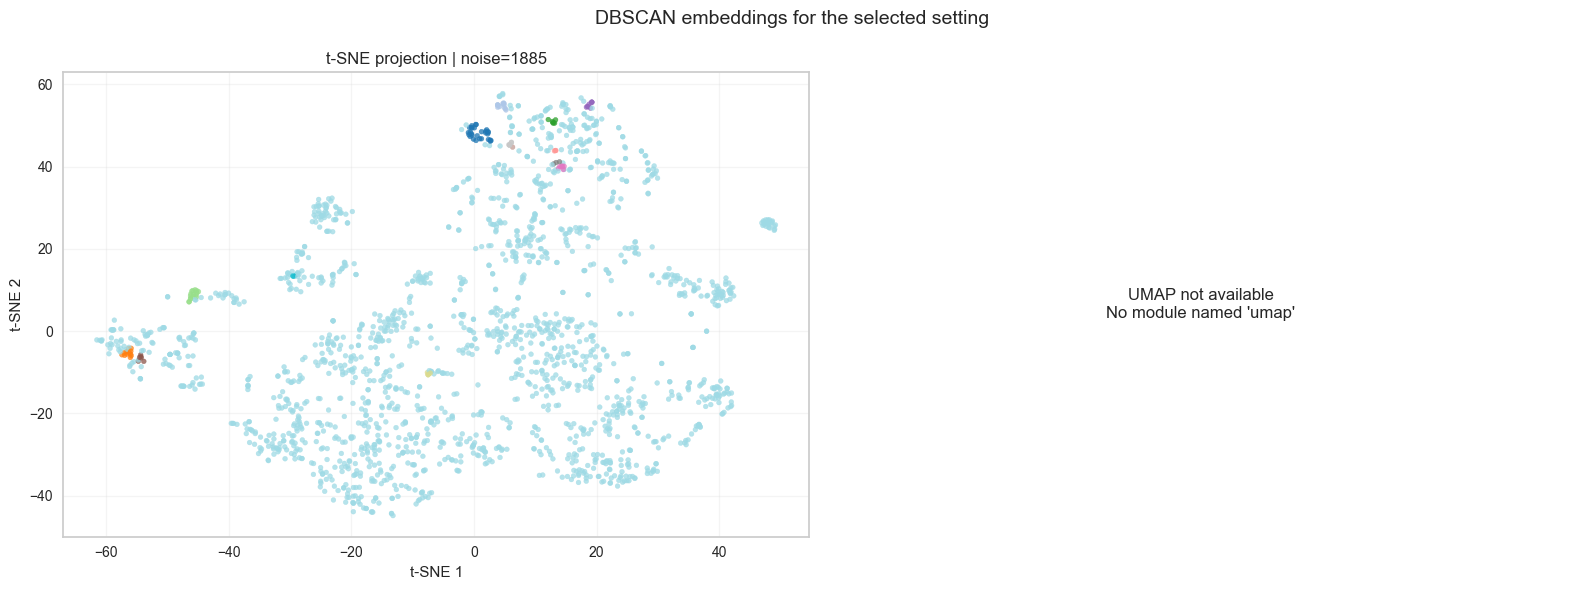

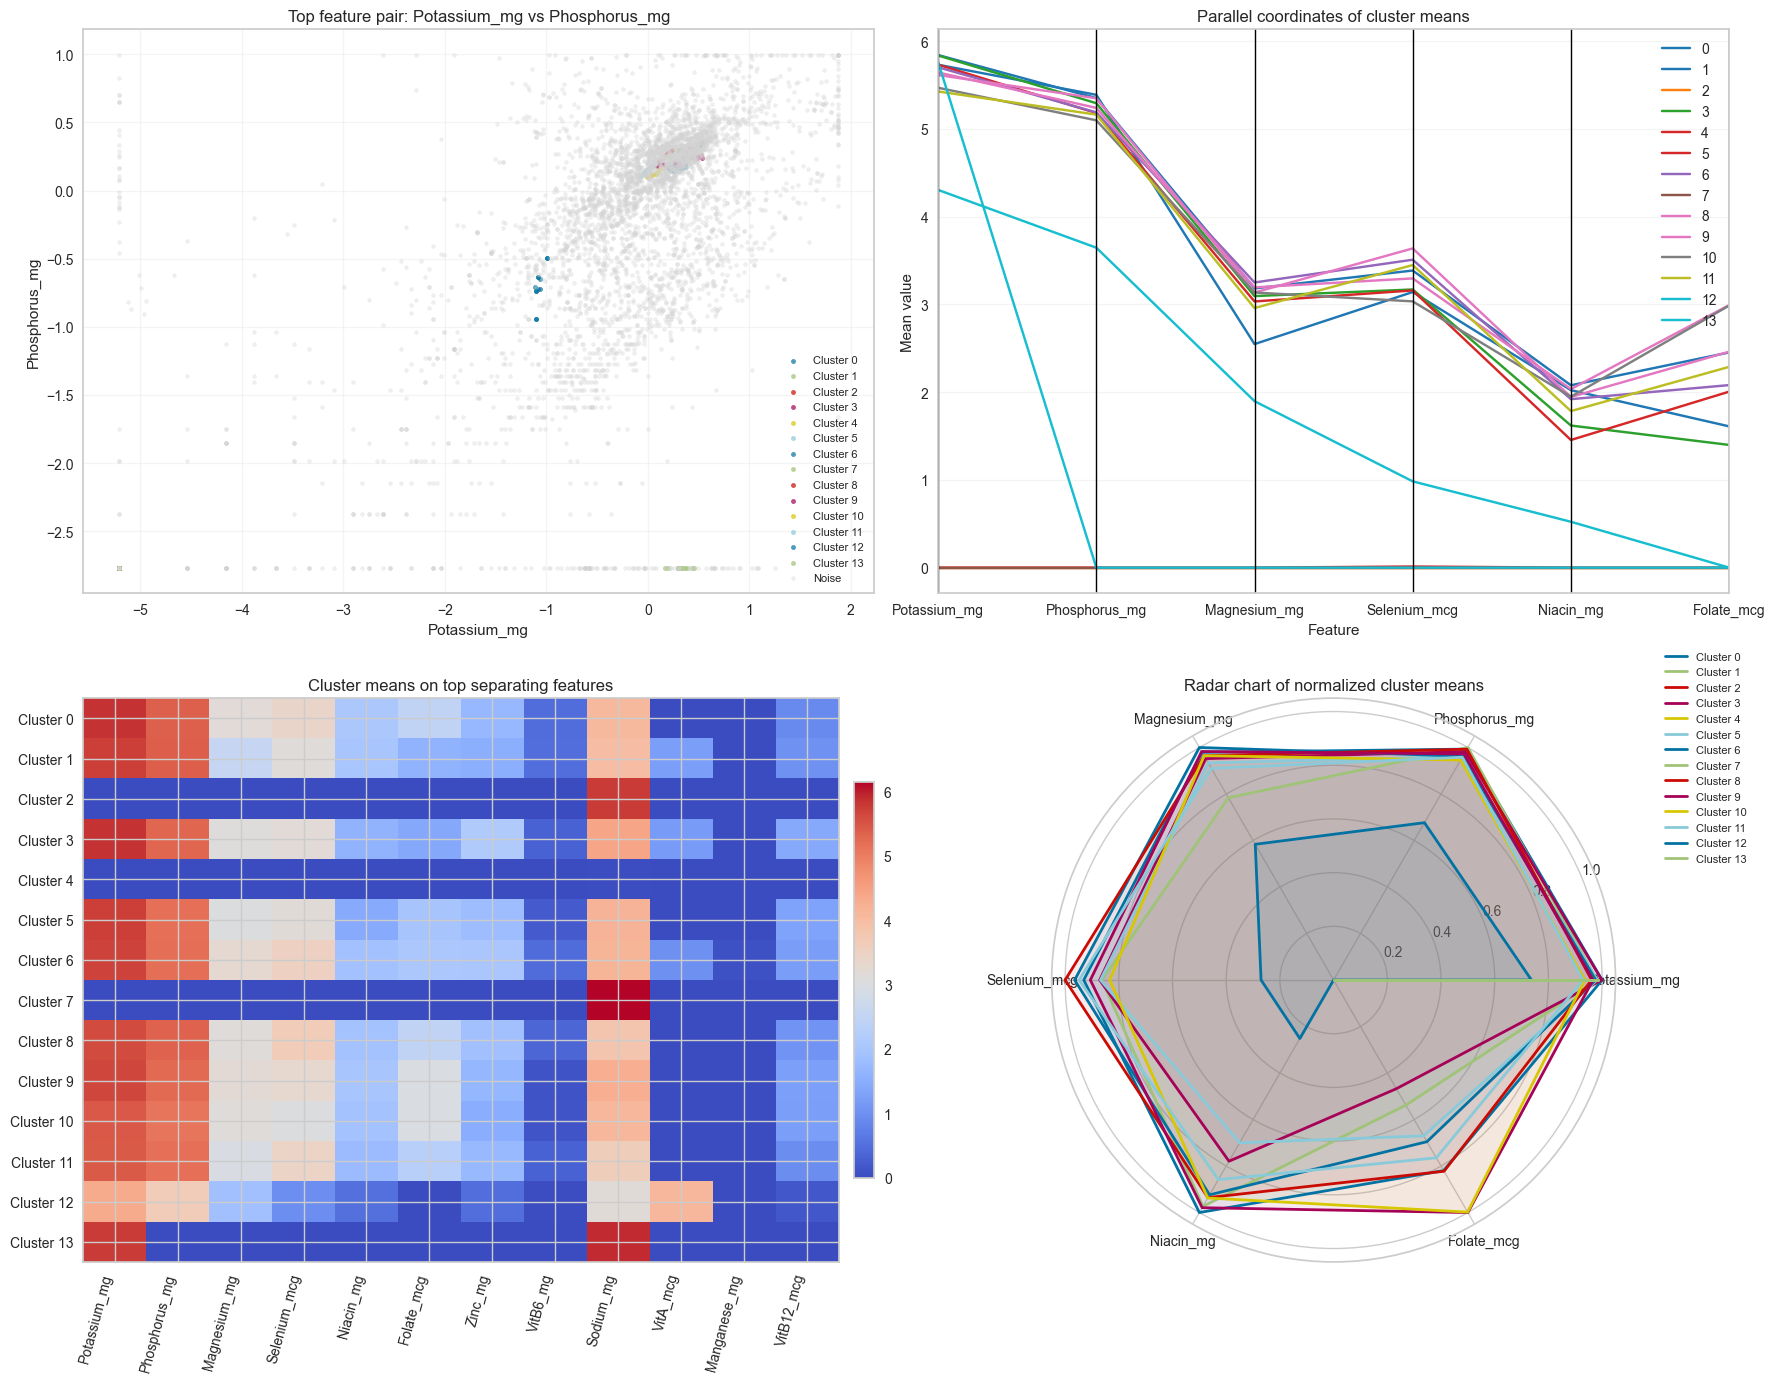

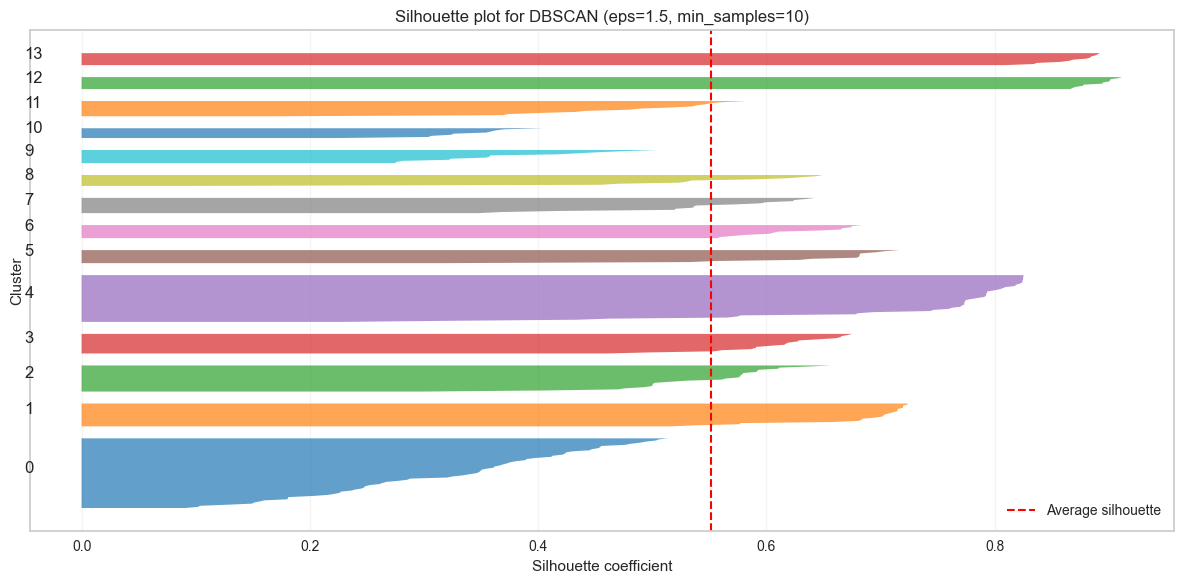

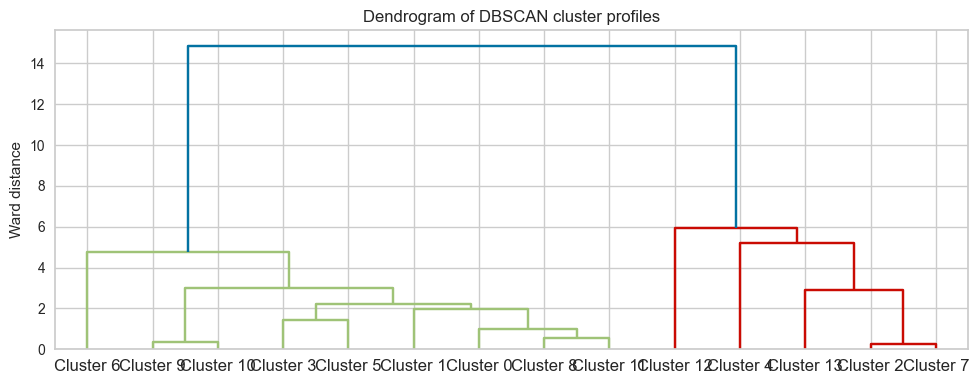

DBSCAN visualization summary:
- selected eps: 1.5
- selected min_samples: 10
- clusters (excluding noise): 14
- noise share: 94.2%
- UMAP was skipped because the optional dependency is not available.


In [27]:
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples
from pandas.plotting import parallel_coordinates
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the best DBSCAN configuration from the sweep cell.
if "dbscan_sweep_df" not in globals():
    raise RuntimeError("Run the DBSCAN sweep cell before this one.")

best_candidates = dbscan_sweep_df.dropna(subset=["silhouette"]).copy()
if best_candidates.empty:
    raise RuntimeError("No DBSCAN setting produced a valid silhouette score.")

best_row = best_candidates.sort_values(
    ["silhouette", "clusters", "noise_pct"], ascending=[False, False, True]
).iloc[0]

best_eps = float(best_row["eps"])
min_samples = int(best_row["min_samples"])
print(f"Using DBSCAN eps={best_eps} and min_samples={min_samples} for the detailed views.")

best_labels = DBSCAN(
    eps=best_eps,
    min_samples=min_samples,
    metric="cityblock",
).fit_predict(X_dbscan)

plot_df = X_dbscan.copy()
plot_df["cluster"] = best_labels
noise_mask = plot_df["cluster"] == -1
non_noise_df = plot_df.loc[~noise_mask].copy()

if non_noise_df.empty or non_noise_df["cluster"].nunique() < 2:
    raise RuntimeError("The selected DBSCAN setting did not produce at least two non-noise clusters.")

# Reconstruct raw transformed values for the sampled rows so the summaries are easier to interpret.
if "X_drop_raw" not in globals():
    drop_mask = model_df[num_cols].notna().all(axis=1)
    X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)

analysis_raw = X_drop_raw.loc[non_noise_df.index].copy()
analysis_raw["cluster"] = non_noise_df["cluster"].values

cluster_sizes = analysis_raw["cluster"].value_counts().sort_index().rename("count")
cluster_sizes_pct = (100 * cluster_sizes / cluster_sizes.sum()).rename("pct")
print("Cluster sizes for the selected DBSCAN setting:")
display(pd.concat([cluster_sizes, cluster_sizes_pct.round(2)], axis=1))

cluster_means = analysis_raw.groupby("cluster")[num_cols].mean()
overall_mean = analysis_raw[num_cols].mean()
cluster_counts = analysis_raw["cluster"].value_counts().sort_index()

ss_between = pd.Series(0.0, index=num_cols)
for cluster_id in cluster_means.index:
    ss_between += cluster_counts.loc[cluster_id] * (cluster_means.loc[cluster_id] - overall_mean) ** 2

ss_total = ((analysis_raw[num_cols] - overall_mean) ** 2).sum(axis=0)
eta2 = (ss_between / ss_total.replace(0, np.nan)).fillna(0).sort_values(ascending=False)

centroids_scaled = non_noise_df.groupby("cluster")[num_cols].mean()
centroid_spread = (centroids_scaled.max(axis=0) - centroids_scaled.min(axis=0)).sort_values(ascending=False)

importance_df = pd.DataFrame(
    {
        "eta2_between_cluster": eta2,
        "centroid_spread_scaled": centroid_spread,
    }
).sort_values(["eta2_between_cluster", "centroid_spread_scaled"], ascending=False)

print("Top columns driving DBSCAN cluster separation:")
display(importance_df.head(20))

top_features = importance_df.head(12).index.tolist()
pair_features = top_features[:2]
parallel_features = top_features[:6]
radar_features = top_features[:6]

print("Top distinguishing features per cluster:")
global_std = analysis_raw[num_cols].std().replace(0, np.nan)
for cluster_id in cluster_means.index:
    z_delta = ((cluster_means.loc[cluster_id] - overall_mean) / global_std).replace([np.inf, -np.inf], np.nan).fillna(0)
    top = z_delta.abs().sort_values(ascending=False).head(10).index
    display(
        pd.DataFrame(
            {
                "feature": top,
                "cluster_mean": cluster_means.loc[cluster_id, top].values,
                "global_mean": overall_mean[top].values,
                "z_delta": z_delta[top].values,
            }
        ).set_index("feature")
    )

# Figure 1: Embeddings using the selected DBSCAN setting
embedding_sample = to_sample(plot_df, max_rows=2000, seed=RANDOM_STATE + 401)
embedding_labels = embedding_sample["cluster"].to_numpy()
embedding_X = embedding_sample.drop(columns=["cluster"])

embedding_results = {}
tsne_perplexity = max(5, min(30, (len(embedding_sample) - 1) // 3))
embedding_results["t-SNE"] = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE,
).fit_transform(embedding_X)

umap_result = None
umap_message = None
try:
    import umap  # type: ignore

    umap_result = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        random_state=RANDOM_STATE,
    ).fit_transform(embedding_X)
    embedding_results["UMAP"] = umap_result
except Exception as exc:
    umap_message = str(exc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, coords) in zip(axes, embedding_results.items()):
    colors = embedding_labels.copy()
    if (colors == -1).any():
        display_colors = colors.astype(int)
        display_colors[colors == -1] = display_colors.max() + 1
        ax.scatter(coords[:, 0], coords[:, 1], c=display_colors, s=12, alpha=0.75, cmap="tab20")
        noise_count = int((colors == -1).sum())
    else:
        ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=12, alpha=0.75, cmap="tab20")
        noise_count = 0
    ax.set_title(f"{name} projection | noise={noise_count}")
    ax.set_xlabel(f"{name} 1")
    ax.set_ylabel(f"{name} 2")
    ax.grid(alpha=0.2)

if len(embedding_results) == 1:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, f"UMAP not available\n{umap_message}", ha="center", va="center", transform=axes[1].transAxes)

fig.suptitle("DBSCAN embeddings for the selected setting", fontsize=14)
plt.tight_layout()
plt.show()

# Figure 2: Feature-pair scatter, centroid heatmap, parallel coordinates, radar chart
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.reshape(-1)

# 1) Feature-pair scatter on the two strongest columns
scatter_df = plot_df.copy()
scatter_df["cluster_label"] = scatter_df["cluster"].astype(str)
scatter_df.loc[scatter_df["cluster"] == -1, "cluster_label"] = "noise"
for cluster_id in sorted(non_noise_df["cluster"].unique()):
    subset = scatter_df[scatter_df["cluster"] == cluster_id]
    axes[0].scatter(
        subset[pair_features[0]],
        subset[pair_features[1]],
        s=10,
        alpha=0.7,
        label=f"Cluster {cluster_id}",
    )
if noise_mask.any():
    noise_subset = scatter_df[scatter_df["cluster"] == -1]
    axes[0].scatter(
        noise_subset[pair_features[0]],
        noise_subset[pair_features[1]],
        s=8,
        alpha=0.35,
        c="lightgray",
        label="Noise",
    )
axes[0].set_title(f"Top feature pair: {pair_features[0]} vs {pair_features[1]}")
axes[0].set_xlabel(pair_features[0])
axes[0].set_ylabel(pair_features[1])
axes[0].legend(fontsize=8, loc="best")
axes[0].grid(alpha=0.2)

# 2) Parallel coordinates on cluster means for the strongest features
parallel_df = cluster_means[parallel_features].reset_index()
parallel_df["cluster"] = parallel_df["cluster"].astype(str)
parallel_coordinates(parallel_df, "cluster", ax=axes[1], colormap="tab10")
axes[1].set_title("Parallel coordinates of cluster means")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Mean value")
axes[1].grid(alpha=0.2)

# 3) Centroid heatmap on the strongest features
heat = cluster_means[top_features].copy()
im = axes[2].imshow(heat.values, aspect="auto", cmap="coolwarm")
axes[2].set_title("Cluster means on top separating features")
axes[2].set_yticks(range(len(heat.index)))
axes[2].set_yticklabels([f"Cluster {i}" for i in heat.index])
axes[2].set_xticks(range(len(top_features)))
axes[2].set_xticklabels(top_features, rotation=75, ha="right")
fig.colorbar(im, ax=axes[2], fraction=0.025, pad=0.02)

# 4) Radar chart on normalized cluster means
radar_df = cluster_means[radar_features].copy()
radar_min = radar_df.min(axis=0)
radar_max = radar_df.max(axis=0)
radar_norm = (radar_df - radar_min) / (radar_max - radar_min).replace(0, 1)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]
ax = axes[3]
ax.remove()
ax = fig.add_subplot(2, 2, 4, polar=True)
for cluster_id in radar_norm.index:
    values = radar_norm.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster_id}")
    ax.fill(angles, values, alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features)
ax.set_title("Radar chart of normalized cluster means")
ax.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.show()

# Figure 3: Silhouette plot for the selected DBSCAN setting
silhouette_values = silhouette_samples(non_noise_df[num_cols], non_noise_df["cluster"])
fig, ax = plt.subplots(figsize=(12, 6))
start = 10
for cluster_id in sorted(non_noise_df["cluster"].unique()):
    cluster_values = silhouette_values[non_noise_df["cluster"].to_numpy() == cluster_id]
    cluster_values.sort()
    size = len(cluster_values)
    end = start + size
    color = plt.cm.tab10(cluster_id % 10)
    ax.fill_betweenx(np.arange(start, end), 0, cluster_values, facecolor=color, alpha=0.7)
    ax.text(-0.05, start + 0.5 * size, str(cluster_id))
    start = end + 10

ax.axvline(x=silhouette_values.mean(), color="red", linestyle="--", linewidth=1.5, label="Average silhouette")
ax.set_title(f"Silhouette plot for DBSCAN (eps={best_eps}, min_samples={min_samples})")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.legend(loc="lower right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Figure 4: Dendrogram of cluster profiles (on cluster means, not on raw points)
profile_z = (cluster_means[top_features] - cluster_means[top_features].mean()) / cluster_means[top_features].std(ddof=0).replace(0, 1)
linkage_matrix = linkage(profile_z.values, method="ward")
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(
    linkage_matrix,
    labels=[f"Cluster {c}" for c in profile_z.index],
    ax=ax,
)
ax.set_title("Dendrogram of DBSCAN cluster profiles")
ax.set_ylabel("Ward distance")
plt.tight_layout()
plt.show()

print("DBSCAN visualization summary:")
print(f"- selected eps: {best_eps}")
print(f"- selected min_samples: {min_samples}")
print(f"- clusters (excluding noise): {non_noise_df['cluster'].nunique()}")
print(f"- noise share: {100 * noise_mask.mean():.1f}%")
if umap_message and umap_result is None:
    print("- UMAP was skipped because the optional dependency is not available.")

## Grouped PCA: Nutrition vs Vitamins

This view does not mix all columns into one PCA. Instead, it computes two separate first principal components:
- one from the nutrition-related columns
- one from the vitamin-related columns

That gives a 2D plot where each axis still has a clear semantic meaning.

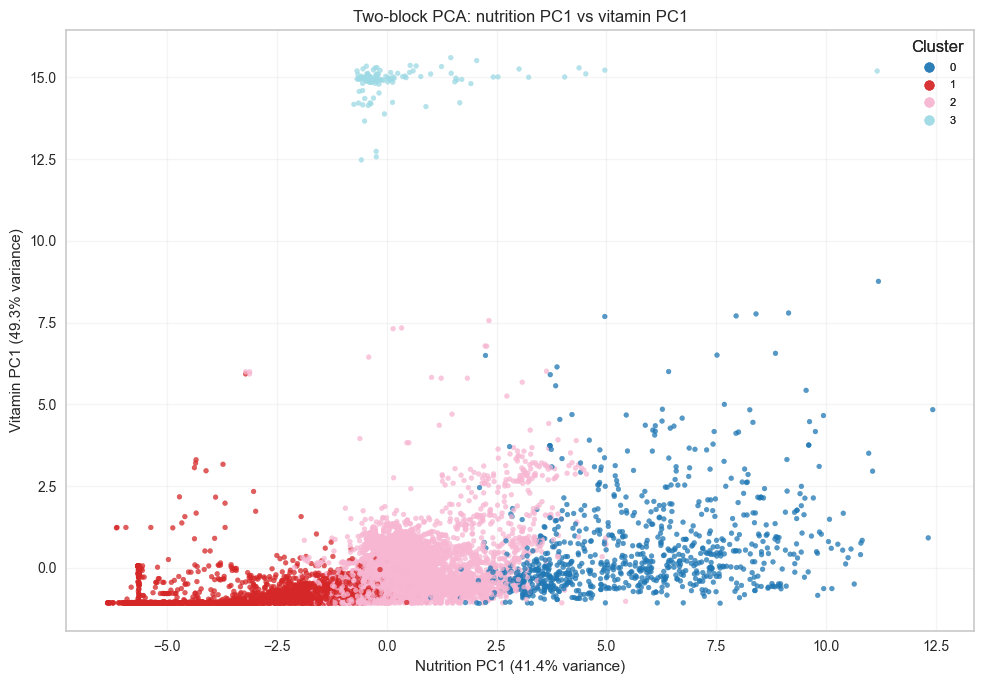

Top nutrition PC1 loadings:


,loading
Copper_mcg,0.462511
Potassium_mg,0.399754
Magnesium_mg,0.399008
Manganese_mg,0.396180
Phosphorus_mg,0.263417
Thiamin_mg,0.233795
Riboflavin_mg,0.199619
Iron_mg,0.195749
Calcium_mg,0.146404
Zinc_mg,0.140820


Top vitamin PC1 loadings:


,loading
VitB6_mg,0.982900
VitE_mg,0.159108
VitB12_mcg,0.086569
VitD2_mcg,0.030035
VitA_mcg,0.012975
VitC_mg,-0.005177


Explained variance ratio:
- Nutrition PC1: 0.414
- Vitamin PC1: 0.493


In [29]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build a two-block PCA view:
# - axis 1: first PC of nutrition-related columns
# - axis 2: first PC of vitamin-related columns
if "X_drop" not in globals():
    drop_mask = model_df[num_cols].notna().all(axis=1)
    X_drop_raw = model_df.loc[drop_mask, num_cols].astype(float)
    drop_scaler = RobustScaler()
    X_drop = pd.DataFrame(
        drop_scaler.fit_transform(X_drop_raw),
        columns=num_cols,
        index=X_drop_raw.index,
    )

vitamin_cols = [c for c in num_cols if c.lower().startswith("vit")]
nutrition_cols = [c for c in num_cols if c not in vitamin_cols]

if len(vitamin_cols) < 2:
    raise RuntimeError("Need at least two vitamin columns to compute a vitamin PCA axis.")
if len(nutrition_cols) < 2:
    raise RuntimeError("Need at least two nutrition columns to compute a nutrition PCA axis.")

nutrition_pca = PCA(n_components=1, random_state=RANDOM_STATE)
vitamin_pca = PCA(n_components=1, random_state=RANDOM_STATE)

nutrition_pc1 = nutrition_pca.fit_transform(X_drop[nutrition_cols]).ravel()
vitamin_pc1 = vitamin_pca.fit_transform(X_drop[vitamin_cols]).ravel()

block_pca_df = pd.DataFrame(
    {
        "nutrition_pc1": nutrition_pc1,
        "vitamin_pc1": vitamin_pc1,
    },
    index=X_drop.index,
)

cluster_labels = labels_k4 if "labels_k4" in globals() and len(labels_k4) == len(block_pca_df) else None

fig, ax = plt.subplots(figsize=(10, 7))
if cluster_labels is not None:
    scatter = ax.scatter(
        block_pca_df["nutrition_pc1"],
        block_pca_df["vitamin_pc1"],
        c=cluster_labels,
        s=12,
        alpha=0.75,
        cmap="tab20",
    )
    legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
    ax.add_artist(legend)
else:
    ax.scatter(
        block_pca_df["nutrition_pc1"],
        block_pca_df["vitamin_pc1"],
        s=12,
        alpha=0.75,
        color="steelblue",
    )

ax.set_title("Two-block PCA: nutrition PC1 vs vitamin PC1")
ax.set_xlabel(f"Nutrition PC1 ({nutrition_pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.set_ylabel(f"Vitamin PC1 ({vitamin_pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

nutrition_loadings = pd.Series(
    nutrition_pca.components_[0],
    index=nutrition_cols,
).sort_values(key=np.abs, ascending=False)
vitamin_loadings = pd.Series(
    vitamin_pca.components_[0],
    index=vitamin_cols,
).sort_values(key=np.abs, ascending=False)

print("Top nutrition PC1 loadings:")
display(nutrition_loadings.head(10).to_frame("loading"))

print("Top vitamin PC1 loadings:")
display(vitamin_loadings.head(10).to_frame("loading"))

print("Explained variance ratio:")
print(f"- Nutrition PC1: {nutrition_pca.explained_variance_ratio_[0]:.3f}")
print(f"- Vitamin PC1: {vitamin_pca.explained_variance_ratio_[0]:.3f}")

## Interpreting Drop-Missing + KMeans (k=4)

This section explains the chosen clustering result in a model-facing way:
- cluster sizes
- nutrient profiles by cluster (mean values in transformed feature space)
- most important columns for clustering (between-cluster variance share and centroid separation)
- top distinguishing features for each cluster

In [26]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Elbow-based KMeans variation using Calinski-Harabasz metric
elbow_rows = []

for variant_name, X_variant in variants.items():
    # Use sampled data for elbow detection speed, then fit final model on full variant
    aggregation_train = to_sample(X_variant, max_rows=5000, seed=RANDOM_STATE + 100)

    kmeans = KMeans(random_state=RANDOM_STATE, n_init=20)
    visualizer = KElbowVisualizer(
        kmeans,
        k=(2, 20),
        metric="calinski_harabasz",
        timings=False,
    )

    visualizer.fit(aggregation_train)
    visualizer.ax.set_title(f"{variant_name}: Elbow using Calinski-Harabasz")
    visualizer.show()

    elbow_k = int(visualizer.elbow_value_) if visualizer.elbow_value_ is not None else 2

    final_kmeans = KMeans(n_clusters=elbow_k, random_state=RANDOM_STATE, n_init=30)
    labels = final_kmeans.fit_predict(X_variant)

    elbow_rows.append(
        {
            "variant": variant_name,
            "elbow_k": elbow_k,
            "silhouette": float(silhouette_score(X_variant, labels)),
            "davies_bouldin": float(davies_bouldin_score(X_variant, labels)),
            "calinski_harabasz": float(calinski_harabasz_score(X_variant, labels)),
        }
    )

elbow_summary_df = pd.DataFrame(elbow_rows)
print("Elbow-based KMeans summary:")
display(elbow_summary_df)

YellowbrickTypeError: The supplied model is not a clustering estimator; try a classifier or regression score visualizer instead!

## Clustering Comparison: Imputed vs Drop-Missing

This section builds two feature variants:
- **Imputed**: median-imputed numeric features (already scaled in the preprocessing step).
- **Drop-missing**: rows with any missing numeric value removed, then robust-scaled.

It then compares:
- K-Means
- Hierarchical Agglomerative Clustering (HAC)
- DBSCAN

The code reports clustering metrics, visualizes 2D PCA projections of clusters, and prints practical recommendations for this dataset.